In [20]:
import warnings
#warnings.simplefilter(action='ignore', category=[FutureWarning, DeprecationWarning, UserWarning])
# import wandb
import pandas as pd
import os 
import seaborn as sns
import torch
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
import matplotlib as mpl 
rcParams['pdf.fonttype'] = 42
import string
import platform

# from adjustText import adjust_text

In [21]:
os.path.dirname(os.path.abspath(''))

from pathlib import Path
micha=True 
if "pop-os" in platform.node():
    ROOT = r"/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/"
elif micha:
    ROOT="/Users/Micha/Library/CloudStorage/OneDrive-UvA/Documents/Projects/in_progress/abishek_startingsmall/code/main/ss-llm/nanoGPT"
else:
    ROOT = r'/gpfs/home4/athamma/repo/ss-llm/nanoGPT/'


In [22]:
#Notes from Micha - 

# Existing figures 
# * Figure 1 from thesis (do you have vector format) - In Canva 
# * Figure 2/3 From thesis (do you have vector format?) - In Canva

# * Figure 4 from thesis (Effect of masking on performance for cross entropy loss)
# * Figure 5 from thesis (Effect of echoic memory for Decay Rate 2)

# * Figure 9 from thesis (can you also make a 100M version?) (BLIMP performance comparison, at individual subtask level)
# ---------------------

# New figures: 
# For the “optimal” mask: 
# For both 10M, 100M:
# * Pairwise validation loss 
# * Pairwise BLIMP aggregate performance 
# * Pairwise reading times  

# Please use code to make aesthetics nice on these ones, like in the example code 

# For many masking settings:
# * The square plot of pairwise (masked/unmasked)  different Echoic memory and slope settings 
# Aesthetics less important here but why not make the labels big etc :) 

# Finally, 
# Is there any chance you still have the generations for the models WITHOUT echoic memory? 
# To give an intuition for listeners during the talk what was going on without echoic memory? 



## Prep data and set things 

In [32]:
#Data Reading and Preprocessing Block
RES_ROOT=Path(ROOT)/'results/final_paper_stuff'
data_dump_path = Path(ROOT) / 'results/rundata.xlsx'##os.path.join(RES_ROOT/'results', r'rundata.xlsx')
run_details_sheet = "Run Details"
loss_sheet = "Loss"
blimp_sheet = "BLIMP"
rt_sheet = "Reading Time"

TASKS = {
    "blimp": ["anaphor_agreement.json", "argument_structure.json", "binding.json",
              "control_raising.json", "determiner_noun_agreement.json", "ellipsis.json",
              "filler_gap.json", "irregular_forms.json", "island_effects.json",
              "npi_licensing.json", "quantifiers.json", "subject_verb_agreement.json"],
    "supplement": ["hypernym.json", "qa_congruence_easy.json", "qa_congruence_tricky.json",
               "subject_aux_inversion.json", "turn_taking.json"]
}
blimp_categories = [[x.split(".json")[0], "blimp"] for x in TASKS["blimp"]]
blimp_categories.extend([[x.split(".json")[0], "supplement"] for x in TASKS["supplement"]])

blimp_name_map = {
    "anaphor_agreement": "Anaphor Agreement", "argument_structure": "Argument Structure", "binding": "Binding", "control_raising": "Control Raising",
    "determiner_noun_agreement": "Determiner Noun Agreement", "ellipsis": "Ellipsis", "filler_gap": "Filler Gap", "irregular_forms": "Irregular Forms",
    "island_effects": "Island Effects", "npi_licensing": "NPI Licensing", "quantifiers": "Quantifiers", "subject_verb_agreement": "Subject Verb Agreement",
    "hypernym": "Hypernym", "qa_congruence_easy": "QA Congruence Easy", "qa_congruence_tricky": "QA Congruence Tricky",
    "subject_aux_inversion": "Subject Aux Inversion", "turn_taking": "Turn Taking"
}


run_data = pd.read_excel(data_dump_path, sheet_name=run_details_sheet) #Data contains a few duplicate runs for same Settings. They have been ignored in the below code wherever necessary
loss_data = pd.read_excel(data_dump_path, sheet_name=loss_sheet)
blimp_data = pd.read_excel(data_dump_path, sheet_name=blimp_sheet)

#Reading time data for Natural Stories SPRT, data from Thesis Time. Can be ignored for now
rt_data = pd.read_excel(data_dump_path, sheet_name=rt_sheet)
rt_subj_data = pd.read_excel(data_dump_path, sheet_name="Reading Time Subjectwise")



#Wil and Wil2 are 2 different fits described in Wilcox et al (Or more specifically, Fit 1 is used in their codebase but Fit 2 is described in the paper)
# Fit 1 - LogRT ~ CharacterLength_c + prev_len_c + prev2_len_c + prev3_len_c + LogFrequencies_c + prev_freq_c + prev2_freq_c + prev3_freq_c + SurprisalScore_c + prev_surp_c + prev2_surp_c + prev3_surp_c
# Fit 2 - LogRT ~ SurprisalScore_c + prev_surp_c + prev2_surp_c + prev3_surp_c + CharacterLength_c*LogFrequencies_c + prev_len_c*prev_freq_c + prev2_len_c*prev2_freq_c + prev3_len_c*prev3_freq_c

reading_time_fit_csv_osh = os.path.join(RES_ROOT, r'surprisal_analysis_results_v2.csv')
reading_time_fit_csv_wil = os.path.join(RES_ROOT, r'surprisal_analysis_results_v3.csv')
reading_time_fit_csv_wil2 = os.path.join(RES_ROOT, r'surprisal_analysis_results_v4.csv')



reading_time_fit_df_osh = pd.read_csv(reading_time_fit_csv_osh)
reading_time_fit_df_wil = pd.read_csv(reading_time_fit_csv_wil)
reading_time_fit_df_wil2 = pd.read_csv(reading_time_fit_csv_wil2)

reading_time_fit_csv_osh_dundee = os.path.join(RES_ROOT, r"surprisal_analysis_results_oshdundee.csv")
reading_time_fit_csv_wil_dundee = os.path.join(RES_ROOT, r"surprisal_analysis_results_wilcoxdundee_v1.csv")
reading_time_fit_csv_wil2_dundee = os.path.join(RES_ROOT, r"surprisal_analysis_results_wilcoxdundee.csv")

reading_time_fit_df_osh_dundee = pd.read_csv(reading_time_fit_csv_osh_dundee)
reading_time_fit_df_wil_dundee = pd.read_csv(reading_time_fit_csv_wil_dundee)
reading_time_fit_df_wil2_dundee = pd.read_csv(reading_time_fit_csv_wil2_dundee)



run_data_unfiltered = run_data

#Filter only for seed 1337 (defaul seed used before Multiseed experiments)
run_data = run_data[run_data["seed"] == 1337].reset_index(drop=True)


In [33]:
#Function to save plots


def save_matplot_fig(fig, save_name, dpi=300, folders_path = None):
    RES_ROOT_path=Path(ROOT)/'results/results/final_paper_stuff/results_figs_fin'
    #path = r'/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/results/log_analyser'
    # RES_ROOT_path = r'/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/results/final_figures_paper'
    # RES_ROOT_path = r'/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/results/final_paper_stuff/results_figs_fin'
    if folders_path is not None:
        path = os.path.join(RES_ROOT_path, folders_path)
    else:
        path = RES_ROOT_path
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    
    path = os.path.join(path, save_name)
     
    #If extension is not provided, add it as pdf
    if not path.endswith(".pdf"):
        if not (path.endswith(".png") or path.endswith(".jpg") or path.endswith(".jpeg")):
            path = path + ".png"

    inp = input(f"Saving figure to {path}. Press Enter to continue, or type 'n' to cancel: ")
    if inp.lower() == 'n':
        print("Figure not saved")
        return
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    
plt.rcParams.update({
    'font.size': 10,          # Base font size
    'axes.titlesize': 12,     # Title font size
    'axes.labelsize': 10,     # Axis label font size
    'xtick.labelsize': 8,     # X-axis tick label font size
    'ytick.labelsize': 8,     # Y-axis tick label font size
    'legend.fontsize': 9,     # Legend font size
    'figure.titlesize': 12    # Figure title font size
})




## Code for Statistical Analysis and Plotting


In [55]:
#Plotting Functions 

def fmt_boot_pval(pval,n_boots=10e4,scientific=False) -> str:
    """convertr bootstrap pvalues to expression that takes into account precision
    (e.g. p=0 will become p < x, with x being determined by number of bootstraps)"""
    if scientific:
        p_str= f'p={pval}' if pval>0 else f'p < {round(1/float(n_boots),int(np.log10(n_boots)+1))}'
    else:
        if pval>0:p_str=f'p={pval}'
        else:p_str='p < {atleast:.{decim}f}'.format(atleast=1/float(n_boots),decim=int(np.log10(n_boots)))
    return(p_str)

def bootstrap_t_onesample(samps_in,pop_mean=0,tail='2s',n_boots=10e4,seed=123):
    """one-sample (paired) bootstrap t-test; returns p-value only

    in:
    - samps: nd.array, shape(n_samples)
        datapoints
    - pop_mean: float, Default=0
        mean to test against
    - tail: str, default: '2s'
        options: '2s','l','r' (for two-tailed,left or right-tailed)
    - n_boots: int; default=10e3
        number of bootstraps (determines precision)

    out:
    -pval: float
        fraction of instances where simulated null distribution returns
        test statistic that is at least as extreme as emprical test stat.
    see also:
    - fmt_boot_pval, function to format the pvalues, changes p=0 into P < (1/n_boots) statement
    dependencies: bootstrap from astropy
    """
    if seed is not None:
      np.random.seed(seed)
    # test stat
    t_func=lambda x,dim:(x.mean(dim)-pop_mean)/(x.std(dim)/np.sqrt(x.shape[dim]))
    # make null distribution
    null_boot_test=t_func(bootstrap(samps_in-samps_in.mean(0)+pop_mean,bootnum=int(n_boots)),1)
    emp_test=t_func(samps_in,0)
    # return p-value as probability of obtaining a test stat at least as extreme under the null
    if tail in ['2s','two','both']:
        left_pval=np.mean(null_boot_test<emp_test)
        right_pval=np.mean(null_boot_test>emp_test)
        return(2*min(left_pval,right_pval))
    elif tail.lower() in ['l','left']:
        return(np.mean(null_boot_test<emp_test))
    elif tail.lower() in ['r','right']:
        return(np.mean(null_boot_test>emp_test))
    else:
        raise ValueError('tail not recognised!')

def bootstrap_analysis(data, pop_mean=0, tail='2s', n_boots=10000, seed=123):
    """
    Perform bootstrap analysis including one-sample t-test and compute 95% CI for the mean.

    Parameters:
    - data (array-like): Sample data.
    - pop_mean (float): Mean to test against.
    - tail (str): Type of the test ('2s' for two-tailed, 'l' for left-tailed, 'r' for right-tailed).
    - n_boots (int): Number of bootstrap samples.
    - seed (int): Seed for the random number generator.

    Returns:
    - dict: Contains the mean, 95% CI for the mean, and formatted p-value.
    """
    if seed is not None:
      np.random.seed(seed)

    # Compute the p-value using the provided function
    p_value = bootstrap_t_onesample(data, pop_mean, tail, n_boots, seed)

    # Format the p-value
    formatted_p_value = fmt_boot_pval(p_value, n_boots)

    # Calculate the sample mean
    sample_mean = np.mean(data)

    # Generate bootstrap samples for the CI of the mean
    bootstrap_samples = bootstrap(data, bootnum=n_boots, bootfunc=np.mean)
    ci_lower, ci_upper = np.percentile(bootstrap_samples, [2.5, 97.5])

    # Compile results
    results = {
        'mean                    ': sample_mean,
        '95%_CI around mean      ': (ci_lower, ci_upper),
        'bootstrap-t-test p_value': formatted_p_value
    }

    return results

def bootstrap(data, bootnum=1000, samples=None, bootfunc=None, seed=False):
    """Performs bootstrap resampling on numpy arrays. (FUNCTION FROM ASTROPY)

    Bootstrap resampling is used to understand confidence intervals of sample
    estimates. This function returns versions of the dataset resampled with
    replacement ("case bootstrapping"). These can all be run through a function
    or statistic to produce a distribution of values which can then be used to
    find the confidence intervals.

    Parameters
    ----------
    data : numpy.ndarray
        N-D array. The bootstrap resampling will be performed on the first
        index, so the first index should access the relevant information
        to be bootstrapped.
    bootnum : int, optional
        Number of bootstrap resamples
    samples : int, optional
        Number of samples in each resample. The default `None` sets samples to
        the number of datapoints
    bootfunc : function, optional
        Function to reduce the resampled data. Each bootstrap resample will
        be put through this function and the results returned. If `None`, the
        bootstrapped data will be returned

    Returns
    -------
    boot : numpy.ndarray

        If bootfunc is None, then each row is a bootstrap resample of the data.
        If bootfunc is specified, then the columns will correspond to the
        outputs of bootfunc.

    """
    if seed != False:
        np.random.seed(seed)

    if samples is None:
        samples = data.shape[0]

    # make sure the input is sane
    if samples < 1 or bootnum < 1:
        raise ValueError("neither 'samples' nor 'bootnum' can be less than 1.")

    if bootfunc is None:
        resultdims = (bootnum,) + (samples,) + data.shape[1:]
    else:
        # test number of outputs from bootfunc, avoid single outputs which are
        # array-like
        try:
            resultdims = (bootnum, len(bootfunc(data)))
        except TypeError:
            resultdims = (bootnum,)

    # create empty boot array
    boot = np.empty(resultdims)

    for i in range(bootnum):
        bootarr = np.random.randint(low=0, high=data.shape[0], size=samples)

#         if seed != False: print(bootarr)
        if bootfunc is None:
            boot[i] = data[bootarr]
        else:
            boot[i] = bootfunc(data[bootarr])

    return boot


def add_sig_stars(ax, df, name_col, pval_col, height_factor=1.1, fontsize=14):
    """Add significance stars to seaborn plot based on p-values."""
    ymin, ymax = ax.get_ylim()

    def pval_to_stars(pval):
#         Using narrow no-break space (\u202f) between stars for tighter spacing
        pval_c = float(pval.split('=')[1]) if 'p=' in pval else float(pval.split('<')[1])
        if pval_c < 0.001: return '*\u200a*\u200a*'
        elif pval_c < 0.01: return '*\u200a*'
        elif pval_c < 0.05: return '*'
        return 'ns'

    xticks = ax.get_xticks()
    xticklabels = [label.get_text() for label in ax.get_xticklabels()]
    name_to_pos = dict(zip(xticklabels, xticks))
    print(df)
    for _, row in df.iterrows():
        if row[name_col] in name_to_pos:
            x_pos = name_to_pos[row[name_col]]
            stars = pval_to_stars(row[pval_col])
            y_pos = ymax + (ymax - ymin) * (height_factor - 1)
            ax.text(x_pos, y_pos, stars,
                  horizontalalignment='center',
                  verticalalignment='center',
                  fontweight='semibold',
                  fontsize=fontsize,
                  family='DejaVu Sans')  # or try 'Arial'

    ax.set_ylim(ymin, ymax + (ymax - ymin) * (height_factor - 1) * 1.2)

def annotate_plot(ax, x1, x2, y, h, asterisk, h_factor=0.9):

    #Ax = ax object
    #x1, x2 = x-coordinates of the bars, give absolute bar id location 0 to n_bar-1
    #y = y-coordinate of the bar, actual value in y axis where you want bar to be placed
    #h = height of the bar
    #asterisk = string to be placed on top of the bar, *,**,***, etc.
    
    if asterisk == '':
        return
    
    #Use annotate pairs to add bars on top of specific columns
    ax = plt.gca() if ax is None else ax
    
    #Calculate y and h based on the data
    # y as 80% of max y limit
    # h as 5% of max y limit
    print("Old y, h", y, h)
    print("Y lim values", ax.get_ylim())
    y = ax.get_ylim()[0] + (ax.get_ylim()[1] - ax.get_ylim()[0]) * h_factor
    h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03

    print("New y, h", y, h)



    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='black')
    
    asterisk_map = {
        "*": "*",
        "**": '*\u200a*',
        "***": '*\u200a*\u200a*'
    }

    if asterisk in ['*', '**', '***']:
        ax.text((x1+x2)*.5, y+h, asterisk_map[asterisk], ha='center', va='bottom', color='black', fontweight='semibold',
                  family='DejaVu Sans')
    else:
        ax.text((x1+x2)*.5, y+h*2, "ns", ha='center', va='bottom', color='black', 
                  fontweight='semibold',
                  family='DejaVu Sans')

def get_asterisk_map(pval):
    pval_c = float(pval.split('=')[1]) if 'p=' in pval else float(pval.split('<')[1])
    if pval_c < 0.001:
        return '***'
    elif pval_c < 0.01:
        return '**'
    elif pval_c < 0.05:
        return '*'
    else:
        return pval

def connect_dots(ax_obj,alpha=.4,col='grey', linewidth=2):
    """ for a given ax_object (from scatterplot or sns.stripplot or the like)
    connect the dots (arbtirary number of columns)"""
    cs=ax_obj.collections
    xcoords=np.vstack([this_cs.get_offsets()[:,0] for this_cs in cs]).T
    ycoords=np.vstack([this_cs.get_offsets()[:,1] for this_cs in cs]).T
    for (xcoord,ycoord) in zip(xcoords,ycoords):
        ax_obj.plot(xcoord,ycoord,alpha=alpha,color=col,linewidth=linewidth)

    return(ax_obj)

#ib = individual blimp
#Different way to connect dots for individual blimp scores, because pair-wise comp 

def connect_dots_ib(ax_obj,alpha=.4,col='grey', linewidth=2):
    """ for a given ax_object (from scatterplot or sns.stripplot or the like)
    connect the dots (arbtirary number of columns)"""
    cs=ax_obj.collections
    xcoords=np.vstack([this_cs.get_offsets()[:,0] for this_cs in cs]).T
    ycoords=np.vstack([this_cs.get_offsets()[:,1] for this_cs in cs]).T
    for (xcoord,ycoord) in zip(xcoords,ycoords):
        
        xcoord = [xcoord[0::2], xcoord[1::2]]
        ycoord = [ycoord[0::2], ycoord[1::2]]
        ax_obj.plot(xcoord,ycoord,alpha=alpha,color=col,linewidth=linewidth)

    return(ax_obj)

def annotate_plot_ib(ax, x1, y_frac, h_frac, asterisk):
    #Ax = ax object
    #x1, x2 = x-coordinates of the bars, give absolute bar id location 0 to n_bar-1
    #y = y-coordinate of the bar, actual value in y axis where you want bar to be placed
    #h = height of the bar
    #asterisk = string to be placed on top of the bar, *,**,***, etc.

    if asterisk == '':
        return

    #Use annotate pairs to add bars on top of specific columns
    ax = plt.gca() if ax is None else ax

    #Calculate y and h based on the data
    y = ax.get_ylim()[0] + (ax.get_ylim()[1] - ax.get_ylim()[0]) * y_frac
    h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * h_frac

    #ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='black')
    #Given a x1, plot within its hue
    ax.plot([x1-0.2, x1-0.2, x1+0.2, x1+0.2], [y, y+h, y+h, y], lw=1.5, c='black')
    asterisk_map = {
        "*": "*",
        "**": '*\u200a*',
        "***": '*\u200a*\u200a*'
    }
    if asterisk in ['*', '**', '***']:
        ax.text((x1+x1)*.5, y+h, asterisk_map[asterisk], ha='center', va='bottom', color='black', fontweight='semibold',
                  family='DejaVu Sans')
    else:
        ax.text((x1+x1)*.5, y+h*2, "ns", ha='center', va='bottom', color='black', fontweight='semibold',
                  family='DejaVu Sans')

def annotate_given_colid_ib(ax, col_id1, plot_data, y_frac, h_frac, conditional_map):

    col_names = [tick.get_text() for tick in ax.get_xticklabels()]
    col_names = {i: col_name for i, col_name in enumerate(col_names)}

    #Annotate within hue 
    #res = annotate_given_colid(ax, 0, 1, plot_data, 90, 2, "score", col_names[0])

    stats_test_subset = plot_data[plot_data["condition"].isin(conditional_map.values())][["condition", "seed", "score"]][plot_data["blimp_task"] == col_names[col_id1]]

    pairwise_diff = stats_test_subset.groupby('seed').apply(lambda x: x[x['condition']==list(conditional_map.values())[1]]["score"].values[0] - x[x['condition']==list(conditional_map.values())[0]]["score"].values[0])
    #print(pairwise_diff)
    res = bootstrap_analysis(pairwise_diff.values,)#alternatively, do: tail='r' to test for delta>0 (one-sided)
    #print(res)
    annotate_plot_ib(ax, col_id1, y_frac, h_frac, get_asterisk_map(res['bootstrap-t-test p_value']))
    
    return res


#add variable for comparison data (Validation Loss or BLIMP scores or Reading Time)
# def annotate_given_colid(ax, col_id1, col_id2, plot_data, y, h, plotcolname, group_by="seed", h_factor=0.9):
#     col_names = [tick.get_text() for tick in ax.get_xticklabels()]
#     col_names = {i: col_name for i, col_name in enumerate(col_names)}
#     #print(col_names)
#     #Using the column names, get the data for each condition #Just do for 0,1 for now
#     #print("Comparing", col_names[col_id1], "and", col_names[col_id2])
#     stats_test_subset = plot_data[plot_data["condition"].isin([col_names[col_id1], col_names[col_id2]])]
#     #Get pairwise differences
#     pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])
#     #print(pairwise_diff)

#     # perform bootstrap-t-test analysis on pairwise values (https://open.lnu.se/index.php/metapsychology/article/view/2058)
#     res = bootstrap_analysis(pairwise_diff.values,)#alternatively, do: tail='r' to test for delta>0 (one-sided)
#     #print(res)
#     #Use results to annotate the plot
#     annotate_plot(ax, col_id1, col_id2, y, h, get_asterisk_map(res['bootstrap-t-test p_value']), h_factor=h_factor)

#     # #Add significance stars
#     # add_sig_stars(ax, pd.DataFrame({"condition": [col_names[col_id1], col_names[col_id2], col_names[col_id1]], "p-value": [res['bootstrap-t-test p_value'], res['bootstrap-t-test p_value'], res['bootstrap-t-test p_value']]}), "condition", "p-value")
#     return res


def annotate_given_colid(ax, col_id1, col_id2, plot_data, y, h, plotcolname, group_by="seed", h_factor=0.9):
    col_names = [tick.get_text() for tick in ax.get_xticklabels()]
    # Ensure col_id1 and col_id2 are valid indices for col_names
    if not (0 <= col_id1 < len(col_names) and 0 <= col_id2 < len(col_names)):
         #print(f"Error: Invalid column indices provided ({col_id1}, {col_id2})")
         return None

    cond1_name = col_names[col_id1]
    cond2_name = col_names[col_id2]

    # Filter data for the two conditions involved
    stats_test_subset = plot_data[plot_data["condition"].isin([cond1_name, cond2_name])]
    if stats_test_subset.empty:
        #print(f"Warning: No data found for conditions '{cond1_name}', '{cond2_name}'.")
        return None

    try:
        # Use pivot_table for safer pairwise difference calculation
        pivot_df = stats_test_subset.pivot_table(index=group_by, columns='condition', values=plotcolname)

        # Check if both condition columns exist after pivot
        if cond1_name not in pivot_df.columns or cond2_name not in pivot_df.columns:
             #print(f"Warning: Pivot table missing one or both conditions: '{cond1_name}', '{cond2_name}'.")
             return None # Cannot calculate difference

        # Calculate difference (col_id1 - col_id2 as per original logic implied by col order)
        pairwise_diff = pivot_df[cond1_name] - pivot_df[cond2_name]
        pairwise_diff = pairwise_diff.dropna() # Remove pairs with missing data

        if pairwise_diff.empty:
            #print(f"Warning: No valid pairs found between '{cond1_name}' and '{cond2_name}' after dropping NaNs.")
            return None

    except ValueError as ve: # Catch pivot errors (e.g., duplicate index/column)
        #print(f"Error pivoting data: {ve}. Check input for duplicate '{group_by}' per 'condition'.")
        # print("Data causing pivot error:")
        # print(stats_test_subset[[group_by, 'condition', plotcolname]].head())
        return None
    except Exception as e:
        #print(f"Unexpected error during pivot/difference calculation: {type(e).__name__}: {e}")
        return None

    # Perform bootstrap analysis
    res = bootstrap_analysis(pairwise_diff.values) # Pass numpy array
    if not isinstance(res, dict) or 'bootstrap-t-test p_value' not in res:
        #print(f"Warning: Bootstrap analysis did not return expected p-value format.")
        return None

    # Annotate plot using the calculated significance
    annotate_plot(ax, col_id1, col_id2, y, h, get_asterisk_map(res['bootstrap-t-test p_value']), h_factor=h_factor)
    return res



In [35]:
#Other Utils
import io
import sys
import contextlib

@contextlib.contextmanager
def silence_prints():
    sys.stdout, old = io.StringIO(), sys.stdout
    try:
        yield
    finally:
        sys.stdout = old


In [36]:
#Settings for plots

#TACL Column size - 7.7 cm
# Gap between columns - 0.6 cm

#For single column plot 
single_col_width = 7.7/2.54
single_col_height = 5/2.54

#For double column plot
double_col_width = (7.7 + 0.6 + 7.7)/2.54
double_col_height = 5/2.54

print("Single Column Width, Height in inches", single_col_width, single_col_height)
print("Double Column Width, Height in inches", double_col_width, double_col_height)

Single Column Width, Height in inches 3.031496062992126 1.968503937007874
Double Column Width, Height in inches 6.299212598425196 1.968503937007874


## Figure 2: Validation Loss and Decay Values

Below figure is for the effect of different decay rates on validation loss and decay values. 

### Left Subplot: Decay Values
- The decay values are plotted for different decay rates (0.5, 1, 2, 3, 4).
- The x-axis is token index for block size (256)

### Right Subplot: Validation Loss
- The validation loss is plotted for different decay rates.
- The x-axis is decay rate, and the y-axis validation loss.
- Data is for 5 seeds for each setting 

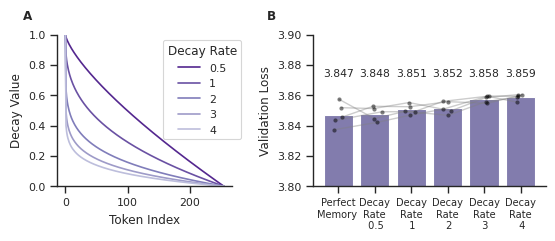

In [31]:
#Block for Figure 2 of paper - A) Different Decay Rates B) Actual Bar chart of Val loss for different decay rates

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    #Filtering data for runs with 10M Dataset, 6 layers, 32 batch size, 44000 iterations, Echoic Memory 1, for masking conditions in Unmasked and PL Decay of 0.5, 1, 2, 3, 4
    def ret_chart_4(fig, axr, option_1=True):
        def get_decay_weight_matrix( n, decay_length, decay_factor=None, decay_type=None, decay_echoic_memory=1):
            
            """
            Get a decay weight matrix for a given context window size n.
            :param n: Context window size for the decay matrix
            :param decay_length: Actual length over which decay happens (usually is supposed to be equal to or greater than n) 
            :param decay_factor: Decay factor for the decay matrix, analogous to weight of the decay
            :param decay_type: Type of decay to apply to the matrix #linear, exponential, inverse_sigmoid, custom_logistic
            :param decay_echoic_memory: Echoic memory for the decay matrix, first n values where "effect of decay" is not applied, where memory is supposedly perfect
            :return: 
            """    
        
            if decay_type == 'linear':
                decay_length = decay_length - decay_echoic_memory+1
                decay_values = torch.linspace(1, 0, decay_length)
                decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
                decay_length = decay_length+decay_echoic_memory-1
                if decay_length != n:
                    assert decay_length > n  #n is context window size and ideally we want decay length to be larger because we are going to cut it off
                    decay_values = decay_values[:n] #Cut off the decay values to the context window size

            elif decay_type == 'exponential':
                decay_length = decay_length - decay_echoic_memory + 1
                nums = torch.linspace(0, 1, decay_length)
                decay_values = torch.exp(-nums * decay_factor)
                decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
                decay_length = decay_length+decay_echoic_memory-1
                if decay_length != n:
                    assert decay_length > n
                    decay_values = decay_values[:n]
        
            elif decay_type == "inverse_sigmoid":
                decay_length = decay_length - decay_echoic_memory + 1 
                nums = torch.linspace(10, -10, decay_length) #assuming hardcoded range between 10 and -10 for now
                decay_values = 1/(1+torch.exp(-decay_factor*nums))
                decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
                decay_length = decay_length+decay_echoic_memory-1

                if decay_length != n:
                    assert decay_length > n
                    decay_values = decay_values[:n]
            
            elif decay_type == "logarithmic":
                decay_length = decay_length - decay_echoic_memory + 1
                nums = torch.linspace(0, 1, decay_length)   
                decay_values = 1-torch.pow(nums,np.e*decay_factor)
                decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
                decay_length = decay_length+decay_echoic_memory-1
                if decay_length != n:
                    assert decay_length > n
                    decay_values = decay_values[:n]
            
            elif decay_type == "exponential_2":
                decay_length = decay_length - decay_echoic_memory + 1
                nums = torch.linspace(0, 1, decay_length)
                decay_values = 1 - torch.pow(nums, 1/(np.e*decay_factor))
                decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
                decay_length = decay_length+decay_echoic_memory-1
                if decay_length != n:
                    assert decay_length > n
                    decay_values = decay_values[:n]
                    
                    
            elif decay_type == "custom_logistic":
                A = 0  # Lower asymptote
                K = 1  # Upper asymptote
                B = 0.8  # Growth rate
                Q = 125  # Related to value at x=0
                nu = 4  # Shape parameter
                M = 4  # Inflection point (time of max growth)
                
                decay_length = decay_length - decay_echoic_memory + 1
                x = torch.linspace(-10, 14.5, decay_length)
                decay_values = A + (K - A) / (1 + Q * torch.exp(-B * (x - M))) ** (1 / nu)
                decay_values = torch.flip(decay_values, [0])
                decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
                decay_length = decay_length+decay_echoic_memory-1
                if decay_length != n:
                    assert decay_length > n
                    decay_values = decay_values[:n]
        
            # Apply the decay values to the lower triangle
        
            indices = torch.arange(n)[:, None] - torch.arange(n)
            lower_triangle = torch.tril(decay_values[indices])
            lower_triangle = lower_triangle.float()
        
            return lower_triangle
        if option_1:
            for i in [1]:
                for dt in ['exponential_2']:
                    #color_map = sns.color_palette("Set2", 6)
                    color_map = sns.color_palette("Purples_r", 7)
                    #color_map = color_map[::-1]
                    color_map = color_map[:6]

                    #color_map = sns.color_palette("Purples_r", 6)
                    decay_rate_list = [0.5, 1, 2, 3, 4]
                    linewidth_list = [4, 3, 2, 1, 1]
                    for j in decay_rate_list:
                        d_vals = get_decay_weight_matrix(256, 256, decay_factor=j, decay_type=dt, decay_echoic_memory=i)
                        plot_vals = d_vals[-1]
                        plot_vals = plot_vals.flip([0])
                        #Annotate 5th value in each curve of the plot using arrow 
                        #axr.annotate(f'{plot_vals[5]:.3f}', (8, plot_vals[5]-0.01) ) 
                        #axr.plot(5, plot_vals[5], ".")
                        #axr.axvline(x=5, color='black', linestyle='--')
                        sns.lineplot(plot_vals, label=f"Decay rate {j}", ax=axr, color=color_map[decay_rate_list.index(j)]) #, linewidth=linewidth_list[decay_rate_list.index(j)])
                axr.set_xlabel('Index')
                axr.set_ylabel('Decay Value')
                #axr.set_xticks(axr.get_xticks().tolist()[2:-1])
                axr.set_ylim(0, 1)
                #axr.set_color_cycle(palette="Purples_r")
                
                axr.legend(axr.get_legend_handles_labels()[0], ["0.5", "1", "2", "3", "4"], bbox_to_anchor=(0.575, 1), loc='upper left', title="Decay Rate")
        else:
            annotate_x = [6,6,6,6]
            annotate_y = [0.01, 0.035, 0.06, 0.075]
            for dt, decay_rate_list in [("linear", 1), ("logarithmic", 0.5), ("logarithmic", 1), ("logarithmic", 2)]:
                d_vals = get_decay_weight_matrix(256, 256, decay_factor=decay_rate_list, decay_type=dt, decay_echoic_memory=1)
                plot_vals = d_vals[-1]
                plot_vals = plot_vals.flip([0])
                
                axr.annotate(f'{plot_vals[5]:.3f}', (annotate_x.pop(), plot_vals[5]-annotate_y.pop()) )
                axr.plot(5, plot_vals[5], ".")
                axr.axvline(x=5, color='black', linestyle='--')
                sns.lineplot(plot_vals, label=f"{dt} Decay Rate {decay_rate_list}", ax=axr)
                
            axr.set_xlabel('Index')
            axr.set_ylabel('Decay Value')
            axr.set_xticks(axr.get_xticks().tolist()[2:-1]+[5])
            axr.set_ylim(0, 1)
            axr.legend(axr.get_legend_handles_labels()[0], ["Linear", "Logarithmic Decay Rate 0.5", "Logarithmic Decay Rate 1", "Logarithmic Decay Rate 2"],  loc='lower left')
            
        return axr



    fig_2_data = run_data_unfiltered[(run_data_unfiltered["curriculum_learning"]==False) &
                                    (run_data_unfiltered["dataset"] == "babylm_full_bpe_8k") &
                                    (run_data_unfiltered["echoic_memory"]==1) &
                                    (~run_data_unfiltered["mask_type"].isin(["exponential", "sigmoid", "linear", "logarithmic"])) &
                                    (run_data_unfiltered["n_layer"]==6) &
                                    (run_data_unfiltered["batch_size"]==32) &
                                    (run_data_unfiltered["num_iterations"]==44000) &
                                    (~run_data_unfiltered["mask_decay_rate"].isin([2000])) &
                                    (run_data_unfiltered["seed"].isin([1337, 42, 2347, 616, 466]))
                                ][["run_id", "output_folder_name", "mask_type", "mask_decay_rate", "echoic_memory", "seed" ]].assign(mask_type=lambda x: pd.Categorical(x["mask_type"], categories=["Non", "exponential_new"], ordered=True)).sort_values(by=["mask_type", "mask_decay_rate"])

    fig_2_data = fig_2_data[~fig_2_data["run_id"].isin([5734459, 5496427, 6617787])]

    #Uncomment below line to see number of rows per mask decay rate pair (Should be 5)
    #print(fig_2_data.groupby(["mask_type", "mask_decay_rate"]).size())
    fig_2_data = fig_2_data.merge(loss_data, on="run_id")

    #Convert string to %g for better display
    fig_2_data["x_label"] = fig_2_data["mask_type"].replace({"linear": "Linear",
                                                            "logarithmic": "Logarithmic",
                                                            "Non": "Perfect\nMemory",
                                                            "sigmoid": "Sigmoid",
                                                            "exponential_new": "Exponential",
                                                            }).astype(str) + " " + fig_2_data["mask_decay_rate"].astype(str).replace("\.0", "", regex=True).replace("0", "")

    #print(fig_2_data)
    #fig_2_data_b = fig_2_data[(fig_2_data["mask_type"] == "exponential_new") & (fig_2_data["mask_decay_rate"] != 2)]
    # fig_2_data["x_label"] = (fig_2_data.x_label.apply(lambda x: x.rstrip("")).map({
    #     "No Mask ": "No\nMask",
    #     "Linear ": "Linear",

    #     # "Exponential 0.5": "Weak\nExponential",
    #     # "Exponential 1": "Intermediate\nExponential",
    #     # "Exponential 2": "Decay\nRate\n2",
    #     # "Logarithmic 0.5": "Weak\nLogarithmic",
    #     # "Logarithmic 1": "Intermediate\nLogarithmic",
    #     # "Logarithmic 2": "Strong\nLogarithmic",
    # }))

    #fig_2_data_a = fig_2_data[fig_2_data["x_label"].isin(["Decay\nRate\n2"])]
    #fig_2_data_a = fig_2_data[fig_2_data["x_label"].isin(["No\nMask", "Decay\nRate\n2"])]

    with sns.axes_style("ticks"), sns.plotting_context("paper", font_scale=.9):

        #rcParams.update(params_two_col) 
        fig, ax = plt.subplots(1, 2, width_ratios=[3, 4])
        fig.set_size_inches(double_col_width, double_col_height)

        sns.barplot(data=fig_2_data, x="x_label", y="val_loss", ax=ax[1], color = sns.color_palette("Purples_r", as_cmap=True)(0.35), errorbar=None)
        sns.stripplot(data=fig_2_data, x="x_label", y="val_loss", ax=ax[1], color="black", alpha=0.5, jitter=0.2, size=3)
        connect_dots(ax[1], alpha=.4, col='grey', linewidth=1)
        #ax[0].set_ylim(3.8, 4.3)
        ax[1].set_ylim(3.8, 4.3)
        color_mapper = {
                            0.5: 'tab:olive',
                            1: 'tab:green',
                            2: 'tab:orange',
                            3: 'tab:red',
                            4: 'tab:purple',
                            2000: 'tab:gray'
                        }

            
        ax[1].set_xticklabels(labels = ax[1].get_xticklabels())
        ax[1].set_xticklabels([x.get_text().replace("Exponential", "Decay\nRate\n") for x in ax[1].get_xticklabels()])

        #ax[1].axhline(y=pd.Series(fig_2_data[fig_2_data["x_label"] == "No Mask"]['val_loss']).values[0], color='red', linestyle='--', lw=1)
        #ax[1]
        
        ax[1].set_ylabel("Validation Loss")
        #ax[0].set_xlabel("")
        ax[1].set_xlabel("")
        ax[1].set_ylim(3.8,3.9)

        for p in ax[1].patches:
            ax[1].annotate(f'{p.get_height():.3f}', 
                           (p.get_x() + p.get_width() / 2., 3.865 ), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
            
        
        
        for text in ax[1].texts:
            text.set_fontsize(0.9 * text.get_fontsize())
        
        ax[0] = ret_chart_4(fig, ax[0])

        ax[0].set_ylabel("Decay Value")
        ax[0].set_xlabel("Token Index")
        for n, axs in enumerate(ax.flat):
            axs.text(-0.2, 1.1, string.ascii_uppercase[n], transform=axs.transAxes, weight='bold')

        #Set x axis x ticks as 0.95 its current size
        ax[1].tick_params(axis='x', labelsize=0.9*ax[1].get_xticklabels()[0].get_fontsize())

        


        sns.despine(bottom=True, left=True, ax=ax[0])
        #sns.despine(bottom=True, left=True, ax=ax[1])
        sns.despine(ax=ax[0])
        sns.despine(ax=ax[1])
        #save_matplot_fig(fig, "val_error_mask_no_mask_fig1_hq_v3", dpi=2000)
        #save_matplot_fig(fig, "val_error_mask_no_mask_fig1_hq_v4.pdf", dpi=2000)

        #save_matplot_fig(fig, "Fig1_val_error_masks.pdf", dpi=3000)

        #fig.suptitle("Effect of Fleeting Memory on Validation Loss (10M)", y = 1.15)
        #save_matplot_fig(fig, "Figure_4.png", dpi=1000)
        #save_matplot_fig(fig, "Figure_4.pdf", dpi=3000)
        plt.subplots_adjust(wspace=0.4)

        #save_matplot_fig(fig, "Figure_2.pdf", dpi=3000)
        save_matplot_fig(fig, "Figure_2_notitle.pdf", dpi=3000)


# Figure 3: Addition of Echoic Memory

### Left Subplot: Decay Curve for Echoic Memory

- The decay values are plotted for Decay Rate 2 with Echoic Memory values of 1, 5, 10

### Right Subplot: Validation Loss for Echoic Memory

- The validation loss is plotted for Echoic Memory values of 1, 5, 10, compared to No Mask setting.

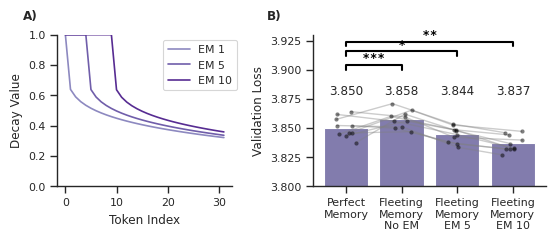

In [76]:
#Block for Figure 3 of paper - A) Different Decay Rates B) Actual Bar chart of Val loss for different decay rates
with silence_prints():
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')


        def ret_chart_5(fig, axr, option_1=True):
                def get_decay_weight_matrix( n, decay_length, decay_factor=None, decay_type=None, decay_echoic_memory=1):
                    
                    """
                    Get a decay weight matrix for a given context window size n.
                    :param n: Context window size for the decay matrix
                    :param decay_length: Actual length over which decay happens (usually is supposed to be equal to or greater than n) 
                    :param decay_factor: Decay factor for the decay matrix, analogous to weight of the decay
                    :param decay_type: Type of decay to apply to the matrix #linear, exponential, inverse_sigmoid, custom_logistic
                    :param decay_echoic_memory: Echoic memory for the decay matrix, first n values where "effect of decay" is not applied, where memory is supposedly perfect
                    :return: 
                    """    
                
                    if decay_type == 'linear':
                        decay_length = decay_length - decay_echoic_memory+1
                        decay_values = torch.linspace(1, 0, decay_length)
                        decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
                        decay_length = decay_length+decay_echoic_memory-1
                        if decay_length != n:
                            assert decay_length > n  #n is context window size and ideally we want decay length to be larger because we are going to cut it off
                            decay_values = decay_values[:n] #Cut off the decay values to the context window size

                    elif decay_type == 'exponential':
                        decay_length = decay_length - decay_echoic_memory + 1
                        nums = torch.linspace(0, 1, decay_length)
                        decay_values = torch.exp(-nums * decay_factor)
                        decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
                        decay_length = decay_length+decay_echoic_memory-1
                        if decay_length != n:
                            assert decay_length > n
                            decay_values = decay_values[:n]
                
                    elif decay_type == "inverse_sigmoid":
                        decay_length = decay_length - decay_echoic_memory + 1 
                        nums = torch.linspace(10, -10, decay_length) #assuming hardcoded range between 10 and -10 for now
                        decay_values = 1/(1+torch.exp(-decay_factor*nums))
                        decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
                        decay_length = decay_length+decay_echoic_memory-1

                        if decay_length != n:
                            assert decay_length > n
                            decay_values = decay_values[:n]
                    
                    elif decay_type == "logarithmic":
                        decay_length = decay_length - decay_echoic_memory + 1
                        nums = torch.linspace(0, 1, decay_length)   
                        decay_values = 1-torch.pow(nums,np.e*decay_factor)
                        decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
                        decay_length = decay_length+decay_echoic_memory-1
                        if decay_length != n:
                            assert decay_length > n
                            decay_values = decay_values[:n]
                    
                    elif decay_type == "exponential_2":
                        decay_length = decay_length - decay_echoic_memory + 1
                        nums = torch.linspace(0, 1, decay_length)
                        decay_values = 1 - torch.pow(nums, 1/(np.e*decay_factor))
                        decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
                        decay_length = decay_length+decay_echoic_memory-1
                        if decay_length != n:
                            assert decay_length > n
                            decay_values = decay_values[:n]
                            
                            
                    elif decay_type == "custom_logistic":
                        A = 0  # Lower asymptote
                        K = 1  # Upper asymptote
                        B = 0.8  # Growth rate
                        Q = 125  # Related to value at x=0
                        nu = 4  # Shape parameter
                        M = 4  # Inflection point (time of max growth)
                        
                        decay_length = decay_length - decay_echoic_memory + 1
                        x = torch.linspace(-10, 14.5, decay_length)
                        decay_values = A + (K - A) / (1 + Q * torch.exp(-B * (x - M))) ** (1 / nu)
                        decay_values = torch.flip(decay_values, [0])
                        decay_values = torch.cat((torch.ones(decay_echoic_memory-1), decay_values))
                        decay_length = decay_length+decay_echoic_memory-1
                        if decay_length != n:
                            assert decay_length > n
                            decay_values = decay_values[:n]
                
                    # Apply the decay values to the lower triangle
                
                    indices = torch.arange(n)[:, None] - torch.arange(n)
                    lower_triangle = torch.tril(decay_values[indices])
                    lower_triangle = lower_triangle.float()
                
                    return lower_triangle
                if option_1:
                    for i in [1, 5, 10]:
                        for dt in ['exponential_2']:
                            #color_map = sns.color_palette("Set2", 6)
                            color_map = sns.color_palette("Purples_r", 6)
                            color_map = color_map[::-1]
                            color_map = color_map[-3:]

                            #color_map = sns.color_palette("Purples_r", 6)
                            decay_rate_list = [2]
                            linewidth_list = [4, 3, 2, 1, 1]
                            for j in decay_rate_list:
                                d_vals = get_decay_weight_matrix(32, 256, decay_factor=j, decay_type=dt, decay_echoic_memory=i)
                                
                                plot_vals = d_vals[-1]
                                plot_vals = plot_vals.flip([0])
                                
                                sns.lineplot(plot_vals, label=f"Decay rate {j}", ax=axr, color=color_map[[1, 5, 10].index(i)]) #, linewidth=linewidth_list[decay_rate_list.index(j)])
                        axr.set_xlabel('Index')
                        axr.set_ylabel('Decay Value')
                        #axr.set_xticks(axr.get_xticks().tolist()[2:-1])
                        axr.set_ylim(0, 1)
                        #axr.set_color_cycle(palette="Purples_r")
                        
                        axr.legend(axr.get_legend_handles_labels()[0], ["EM 1", "EM 5", "EM 10"], bbox_to_anchor=(0.575, 1), loc='upper left')        

                        #print("Done")
                return axr


        fig_3_data = run_data_unfiltered[(run_data_unfiltered["curriculum_learning"]==False) &
                                        (run_data_unfiltered["dataset"] == "babylm_full_bpe_8k") &
                                        (run_data_unfiltered["echoic_memory"].isin([1, 5, 10])) &
                                        (~run_data_unfiltered["mask_type"].isin(["exponential", "sigmoid", "linear", "logarithmic"])) &
                                        (run_data_unfiltered["n_layer"]==6) &
                                        (run_data_unfiltered["batch_size"]==32) &
                                        (run_data_unfiltered["num_iterations"]==44000) &
                                        (~run_data_unfiltered["mask_decay_rate"].isin([0.5, 1, 3, 4, 2000])) 
                                        #(run_data_unfiltered["seed"].isin([1337, 42, 2347, 616, 466]))
                                    ][["run_id", "output_folder_name", "mask_type", "mask_decay_rate", "echoic_memory", "seed" ]].assign(mask_type=lambda x: pd.Categorical(x["mask_type"], categories=["Non", "exponential_new"], ordered=True)).sort_values(by=["mask_type", "mask_decay_rate"])

        fig_3_data = fig_3_data[~fig_3_data["run_id"].isin([5734459, 5496427, 6617787])]

        #Uncomment below line to see number of rows per mask decay rate pair (Should be 10)
        #print(fig_3_data.groupby(["mask_type", "mask_decay_rate", "echoic_memory"]).size())
        fig_3_data = fig_3_data.merge(loss_data, on="run_id")
        fig_3_data["condition"] = (fig_3_data["mask_type"].astype(str).replace({"Non": "nomask", "exponential_new": "ee"}) + fig_3_data["mask_decay_rate"].astype(int).astype(str).str.zfill(3).replace("000","") + "_EM" + fig_3_data["echoic_memory"].astype(str).str.zfill(2))


        #Convert string to %g for better display
        fig_3_data["x_label"] = fig_3_data["mask_type"].replace({"linear": "Linear",
                                                                "logarithmic": "Logarithmic",
                                                                "Non": "No Mask",
                                                                "sigmoid": "Sigmoid",
                                                                "exponential_new": "Exponential",
                                                                }).astype(str) + " " + fig_3_data["echoic_memory"].astype(str)
                                                                #fig_3_data["mask_decay_rate"].astype(str).replace("\.0", "", regex=True).replace("0", "")


        condition_triplet_map = {"nomask_EM01": "No\nMask", 
                                "ee002_EM01": "Mask\nNo EM", 
                                "ee002_EM05": "Mask\nEM 5", 
                                "ee002_EM10": "Mask\nEM 10"}

        condition_triplet_map = {"nomask_EM01": "Perfect\nMemory", 
                                "ee002_EM01": "Fleeting\nMemory\nNo EM", 
                                "ee002_EM05": "Fleeting\nMemory\nEM 5",
                                "ee002_EM10": "Fleeting\nMemory\nEM 10"}

        fig_3_data["condition"] = pd.Categorical(fig_3_data["condition"], categories=["nomask_EM01", "ee002_EM01", "ee002_EM05", "ee002_EM10"], ordered=True)
        
        fig_3_data["condition"] = fig_3_data["condition"].map(condition_triplet_map)

        #print(fig_3_data)

        with sns.axes_style("ticks"), sns.plotting_context("paper", font_scale=.9):

            #rcParams.update(params_two_col) 
            fig, ax = plt.subplots(1, 2, width_ratios=[3,4])
            fig.set_size_inches(double_col_width, double_col_height)

            sns.barplot(data=fig_3_data, x="condition", y="val_loss", ax=ax[1], color = sns.color_palette("Purples_r", as_cmap=True)(0.35), errorbar=None)
            sns.stripplot(data=fig_3_data, x="condition", y="val_loss", ax=ax[1], color="black", alpha=0.5, jitter=0.2, size=3)
            ax[1].set_ylim(3.8,3.93)

            connect_dots(ax[1], alpha=.4, col='grey', linewidth=1)

            res = annotate_given_colid(ax[1], 1, 0, fig_3_data, 3.885, 0.002, "val_loss", h_factor=0.77)
            stats_test = []
            stats_test.append({**{"pair_A":"nomask_EM01", "pair_B":"ee002_EM01"} , **res})
            res = annotate_given_colid(ax[1], 2, 0, fig_3_data, 3.885, 0.002, "val_loss", h_factor=0.86)
            stats_test.append({**{ "pair_A":"nomask_EM01", "pair_B":"ee002_EM05"} ,**res})
            res = annotate_given_colid(ax[1], 3, 0, fig_3_data, 3.885, 0.002, "val_loss", h_factor=0.95)
            stats_test.append({**{"pair_A":"nomask_EM01", "pair_B":"ee002_EM10"},**res})

            #ax[0].set_ylim(3.8, 4.3)
            #ax[1].set_ylim(3.8, 4.3)
            color_mapper = {
                                0.5: 'tab:olive',
                                1: 'tab:green',
                                2: 'tab:orange',
                                3: 'tab:red',
                                4: 'tab:purple',
                                2000: 'tab:gray'
                            }

                
            ax[1].set_xticklabels(labels = ax[1].get_xticklabels())
            ax[1].set_xticklabels([x.get_text().replace("Exponential", "Decay\nRate\n") for x in ax[1].get_xticklabels()])

            #ax[1].axhline(y=pd.Series(fig_3_data[fig_3_data["x_label"] == "No Mask"]['val_loss']).values[0], color='red', linestyle='--', lw=1)
            #ax[1]
            
            ax[1].set_ylabel("Validation Loss")
            #ax[0].set_xlabel("")
            ax[1].set_xlabel("")

            for p in ax[1].patches:
                ax[1].annotate(f'{p.get_height():.3f}', 
                               (p.get_x() + p.get_width() / 2., 3.87 ), 
                               ha='center', va='center', xytext=(0, 10), textcoords='offset points')
                #p.get_height()+0.015

            
            ax[0] = ret_chart_5(fig, ax[0])

            ax[0].set_ylabel("Decay Value")
            ax[0].set_xlabel("Token Index")
            for n, axs in enumerate(ax.flat):
                axs.text(-0.2, 1.1, string.ascii_uppercase[n]+")", transform=axs.transAxes, weight='bold')

            sns.despine(bottom=True, left=True, ax=ax[0])
            #sns.despine(bottom=True, left=True, ax=ax[1])
            sns.despine(ax=ax[0])
            sns.despine(ax=ax[1])
            #save_matplot_fig(fig, "val_error_mask_no_mask_fig1_hq_v3", dpi=2000)
            #save_matplot_fig(fig, "val_error_mask_no_mask_fig1_hq_v4.pdf", dpi=2000)

            #save_matplot_fig(fig, "Fig1_val_error_masks.pdf", dpi=3000)

            #fig.suptitle("Effect of Masking on Validation Loss (10M)", y = 1.15)
            #save_matplot_fig(fig, "Figure_4.png", dpi=1000)
            #save_matplot_fig(fig, "Figure_4.pdf", dpi=3000)
            
            plt.subplots_adjust(wspace=0.4)
            #save_matplot_fig(fig, "Figure_3.pdf", dpi=3000)
            #
            # save_matplot_fig(fig, "Figure_3_notitle.pdf", dpi=3000)

# Figure 4

### 2x2 Subplots: Validation Loss and BLIMP Score for 10M and 100M Data


In [13]:
from pdb import set_trace

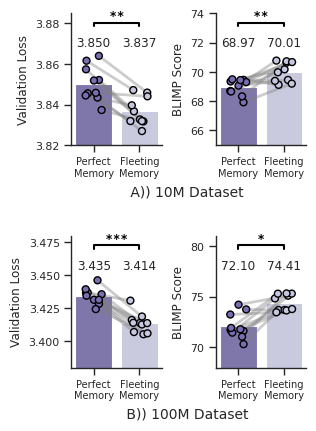

In [74]:
save=False
#Figure 4 - BLIMP Results for 10M Dataset No Mask vs Mask 2 EM 10 (Best condition), and Same for 100M
# 4 Figures - 2 for 10M and 2 for 100M
with silence_prints():
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')

        fig_4_data = run_data_unfiltered[(run_data_unfiltered["curriculum_learning"]==False) &
                                        (run_data_unfiltered["batch_size"]==32) &
                                        (run_data_unfiltered["num_iterations"]==44000) &
                                        (run_data_unfiltered["n_layer"]==6) &
                                        (run_data_unfiltered["dataset"].isin(["babylm_full_bpe_8k", "babylm_full_bpe_100M_8k"])) &
                                        
                                        (
                                            (
                                                (run_data_unfiltered["echoic_memory"].isin([10]) & (run_data_unfiltered["mask_decay_rate"].isin([2]))) & (run_data_unfiltered["mask_type"].isin(["exponential_new"]))
                                            ) |
                                                (run_data_unfiltered["mask_type"].isin(["Non"]))
                                        )
                                    
                                        ][["run_id", "output_folder_name", "mask_type", "mask_decay_rate", "echoic_memory", "seed", "dataset"]].assign(mask_type=lambda x: pd.Categorical(x["mask_type"], categories=["Non", "exponential_new"], ordered=True)).sort_values(by=["mask_type", "mask_decay_rate"])
                                                
        fig_4_data = fig_4_data[~fig_4_data["run_id"].isin([5734459, 5496427, 6617787, 8465077])]

        #print(fig_4_data.groupby(["dataset", "mask_type", "mask_decay_rate", "echoic_memory"]).size())

        #fig_4_data
        fig_4_data = fig_4_data.merge(loss_data, on="run_id")
        fig_4_data = fig_4_data.merge(blimp_data[["run_id", "blimp_avg"]], on="run_id")
        fig_4_data["condition"] = (fig_4_data["mask_type"].astype(str).replace({"Non": "nomask", "exponential_new": "ee"}) + fig_4_data["mask_decay_rate"].astype(int).astype(str).str.zfill(3).replace("000","") + "_EM" + fig_4_data["echoic_memory"].astype(str).str.zfill(2))

        condition_triplet_map = {"nomask_EM01": "Perfect\nMemory",
                                "ee002_EM10": "Fleeting\nMemory"}

        fig_4_data["condition"] = pd.Categorical(fig_4_data["condition"], categories=["nomask_EM01", "ee002_EM10"], ordered=True)
        fig_4_data = fig_4_data.sort_values(by=["dataset", "condition", "seed"])

        fig_4_data["condition"] = fig_4_data["condition"].map(condition_triplet_map)

        fig_4_data["dataset"] = fig_4_data["dataset"].replace({"babylm_full_bpe_8k": "10M", "babylm_full_bpe_100M_8k": "100M"})

        #fig_4_data

        with sns.axes_style("ticks"), sns.plotting_context("paper", font_scale=.9):
            #fig, ax1 = plt.subplots(2, 1)
            fig = plt.figure(figsize=(single_col_width, 2*single_col_height))
            subfigs = fig.subfigures(nrows=2, ncols=1, hspace=0.3)
            # subfigs = plt.figure(figsize=(single_col_width, 2*single_col_height)
            #                      ).subfigures(nrows=2, ncols=1, hspace=0.2)
            #fig.set_size_inches(8, 8)

            for i, dataset in enumerate(["10M", "100M"]):
                letter_char = "A)" if i == 0 else "B)"
                subfigs[i].suptitle(f" {letter_char}) {dataset} Dataset", y = -0.12, fontsize=10)
                ax = subfigs[i].subplots(1, 2)
                #subfigs[i].suptitle(f"Effect of Masking on Validation Loss and BLIMP Score ({dataset})", y = 1.0) 
                for plotting_measure in ["val_loss", "blimp_avg"]:
                    fig_4_data_subset = fig_4_data[fig_4_data["dataset"] == dataset]
                    #axr = ax[i][0] if plotting_measure == "val_loss" else ax[i][1]
                    axr = ax[0] if plotting_measure == "val_loss" else ax[1]
                    sns.barplot(data=fig_4_data_subset, x="condition", y=plotting_measure, hue = "condition",
                                ax=axr, palette = "Purples_r", errorbar=None)
                    sns.stripplot(data=fig_4_data_subset, x="condition", y=plotting_measure, hue = "condition",
                                  ax=axr, palette="Purples_r", alpha=1, 
                                  jitter=0.2, edgecolor="black", linewidth=1)
                    #axr.set_ylim(3.8, 4.3) if plotting_measure == "val_loss" else axr.set_ylim(50, 100)
                    if plotting_measure == "val_loss" and dataset == "10M":
                        axr.set_ylim(3.82, 3.885)
                    elif plotting_measure == "val_loss" and dataset == "100M":
                        axr.set_ylim(3.38, 3.48)
                    elif plotting_measure == "blimp_avg" and dataset == "10M":
                        axr.set_ylim(65, 74)
                    else:
                        axr.set_ylim(68, 81)
                    breakpoint()
                    
                    connect_dots(axr, alpha=.4, col='grey', linewidth=2)
                    res = annotate_given_colid(axr, 1, 0, fig_4_data_subset, 3.885, 0.002, plotting_measure, h_factor=0.9)
                    axr.set_ylabel("Validation Loss" if plotting_measure == "val_loss" else "BLIMP Score")
                    axr.set_xlabel("")
                    axr.set_xticklabels(axr.get_xticklabels(), size=axr.xaxis.get_ticklabels()[0].get_fontsize()*0.9)

                    if plotting_measure == "val_loss":    
                        
                        #Set patch height as x percent of y lim max - y lim min
                        patch_height = (axr.get_ylim()[1] - axr.get_ylim()[0]) * 0.67 + axr.get_ylim()[0]
                        print(patch_height)
                        
                        for p in axr.patches:
                            axr.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., patch_height ), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
                            #p.get_height()+0.015
                    else:
                        if dataset == "10M":
                            patch_height = (axr.get_ylim()[1] - axr.get_ylim()[0]) * 0.67 + axr.get_ylim()[0]
                        else:
                            patch_height = (axr.get_ylim()[1] - axr.get_ylim()[0]) * 0.67 + axr.get_ylim()[0]
                        for p in axr.patches:
                            axr.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., patch_height ), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
                            #p.get_height()+0.015

            
                for n, axs in enumerate(ax.flat):
                    if n == 0: #Top left
                        sns.despine(ax=axs)
                    elif n == 1: #Top right
                        sns.despine(ax=axs)            
                    elif n == 2: #Bottom left
                        sns.despine(ax=axs)
                    else: #Bottom right
                        sns.despine(ax=axs)
                    
            plt.subplots_adjust(wspace=0.6)
        #Set common title for row 1
        
        #TODO: Change colors of strip plot points from to other notebook's colors
        if save:
            save_matplot_fig(fig, "Figure_4_v2.pdf", dpi=3000)

# Figure 4, redone by Micha (more readable?)

### custom funcs 

In [53]:
del print
from builtins import print

In [71]:
### some additional plottings
def annotate_paired_comparison_stats(ax, data, value_col, group_col, condition_col, cond1, cond2, h_factor=0.9):
    """
    Performs paired bootstrap t-test between two conditions and annotates the plot.

    Args:
        ax: The matplotlib axes object.
        data: DataFrame containing the data.
        value_col: Name of the column with values to compare.
        group_col: Name of the column to group by for pairing (e.g., 'seed').
        condition_col: Name of the column containing the condition labels.
        cond1: Label of the first condition.
        cond2: Label of the second condition.
        h_factor: Vertical positioning factor for the annotation bracket (passed to annotate_plot).
    """
    try:
        # Ensure data has the necessary columns and conditions
        required_cols = [value_col, group_col, condition_col]
        if not all(col in data.columns for col in required_cols):
            # Skip annotation if columns are missing
            return None
        
        data_filtered = data[data[condition_col].isin([cond1, cond2])].copy()
        if data_filtered[condition_col].nunique() < 2:
            # Skip if only one condition present
            return None

        # Pivot to get paired data
        data_pivot = data_filtered.pivot_table(index=group_col, columns=condition_col, values=value_col)

        # Calculate differences, handling potential missing pairs
        diff = (data_pivot[cond2] - data_pivot[cond1]).dropna()

        if diff.empty:
            # Skip if no paired differences can be calculated
            return None

        # Perform bootstrap analysis
        # Assuming bootstrap_analysis returns a dict with 'bootstrap-t-test p_value'
        res = bootstrap_analysis(diff.values) 
        pval_str = res.get('bootstrap-t-test p_value', '')
        asterisk = get_asterisk_map(pval_str) if pval_str else ''

        # Annotate the plot using the existing helper
        # Pass dummy y/h as annotate_plot calculates them internally
        annotate_plot(ax, 0, 1, 0, 0, asterisk, h_factor=h_factor) 
        
        return res
    except Exception as e:
        # Optionally log the error, but don't crash the plotting
        # print(f"Annotation failed for {cond1} vs {cond2}: {e}") 
        return None
def annotate_plot(ax, x1, x2, y, h, asterisk, h_factor=0.9):
    #Ax = ax object
    #x1, x2 = x-coordinates of the bars, give absolute bar id location 0 to n_bar-1
    #y = y-coordinate (ignored, recalculated based on h_factor)
    #h = height (ignored, recalculated based on y-axis range)
    #asterisk = string to be placed on top of the bar, *,**,***, etc.
    #h_factor = fractional height on y-axis to place the bottom of the bracket

    if asterisk == '':
        return

    ax = plt.gca() if ax is None else ax
    
    #Calculate y and h based on the data range and h_factor
    plot_ymin, plot_ymax = ax.get_ylim()
    yrange = plot_ymax - plot_ymin
    y_pos = plot_ymin + yrange * h_factor # Position bottom of bracket
    h_val = yrange * 0.03               # Height of vertical ticks

    # Check if calculated position is too high, adjust if needed
    # Ensure there's space for the text above the bracket
    max_allowable_y = plot_ymax - 2.5 * h_val 
    y_pos = min(y_pos, max_allowable_y)


    ax.plot([x1, x1, x2, x2], [y_pos, y_pos+h_val, y_pos+h_val, y_pos], lw=1.5, c='black')

    asterisk_map = {
        "*": "*",
        "**": '*\u200a*',
        "***": '*\u200a*\u200a*'
    }

    # Use narrow no-break space for ns as well for consistency if desired
    text_to_display = asterisk_map.get(asterisk, "ns") 
    
    ax.text((x1+x2)*.5, y_pos+h_val, text_to_display, ha='center', va='bottom', color='black', fontweight='semibold',
              family='DejaVu Sans') # Ensure font is available


### plotting cell

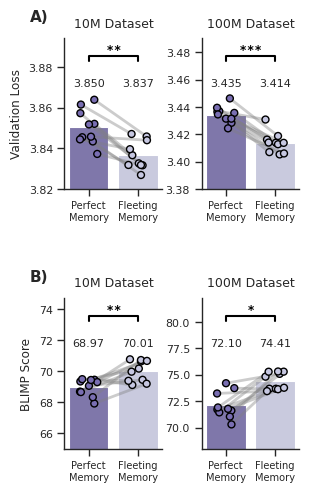

In [79]:
#Figure 4 - BLIMP Results for 10M Dataset No Mask vs Mask 2 EM 10 (Best condition), and Same for 100M
# 4 Figures - Reorganized: Top row Val Loss (10M left, 100M right), Bottom row BLIMP (10M left, 100M right)
save=True
import matplotlib.patches as mpatches
# Assume necessary helper functions (connect_dots, bootstrap_analysis, get_asterisk_map, annotate_plot, annotate_paired_comparison_stats)
# and variables (run_data_unfiltered, loss_data, blimp_data, single_col_width, single_col_height, save_matplot_fig) are defined elsewhere.

# Figure 4 - BLIMP Results for 10M Dataset No Mask vs Mask 2 EM 10 (Best condition), and Same for 100M
# 4 Figures - Reorganized: Top row Val Loss (10M left, 100M right), Bottom row BLIMP (10M left, 100M right)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    # --- Data Preparation (Identical) ---
    fig_4_data = run_data_unfiltered[(run_data_unfiltered["curriculum_learning"]==False) &
                                    (run_data_unfiltered["batch_size"]==32) &
                                    (run_data_unfiltered["num_iterations"]==44000) &
                                    (run_data_unfiltered["n_layer"]==6) &
                                    (run_data_unfiltered["dataset"].isin(["babylm_full_bpe_8k", "babylm_full_bpe_100M_8k"])) &
                                    (
                                        (
                                            (run_data_unfiltered["echoic_memory"].isin([10]) & (run_data_unfiltered["mask_decay_rate"].isin([2]))) & (run_data_unfiltered["mask_type"].isin(["exponential_new"]))
                                        ) |
                                            (run_data_unfiltered["mask_type"].isin(["Non"]))
                                    )
                                    ][["run_id", "output_folder_name", "mask_type", "mask_decay_rate", "echoic_memory", "seed", "dataset"]].assign(mask_type=lambda x: pd.Categorical(x["mask_type"], categories=["Non", "exponential_new"], ordered=True)).sort_values(by=["mask_type", "mask_decay_rate"])

    fig_4_data = fig_4_data[~fig_4_data["run_id"].isin([5734459, 5496427, 6617787, 8465077])]
    fig_4_data = fig_4_data.merge(loss_data, on="run_id")
    fig_4_data = fig_4_data.merge(blimp_data[["run_id", "blimp_avg"]], on="run_id")
    fig_4_data["condition"] = (fig_4_data["mask_type"].astype(str).replace({"Non": "nomask", "exponential_new": "ee"}) +
                                fig_4_data["mask_decay_rate"].fillna(0).astype(int).astype(str).str.zfill(3).replace("000","") +
                                "_EM" + fig_4_data["echoic_memory"].fillna(1).astype(int).astype(str).str.zfill(2))
    condition_triplet_map = {"nomask_EM01": "Perfect\nMemory", "ee002_EM10": "Fleeting\nMemory"}
    valid_conditions = list(condition_triplet_map.keys())
    fig_4_data = fig_4_data[fig_4_data["condition"].isin(valid_conditions)]
    fig_4_data["condition"] = pd.Categorical(fig_4_data["condition"], categories=["nomask_EM01", "ee002_EM10"], ordered=True)
    fig_4_data["condition_label"] = fig_4_data["condition"].map(condition_triplet_map)
    fig_4_data["condition_label"] = pd.Categorical(fig_4_data["condition_label"], categories=["Perfect\nMemory", "Fleeting\nMemory"], ordered=True)
    fig_4_data["dataset"] = fig_4_data["dataset"].replace({"babylm_full_bpe_8k": "10M", "babylm_full_bpe_100M_8k": "100M"})
    fig_4_data["dataset"] = pd.Categorical(fig_4_data["dataset"], categories=["10M", "100M"], ordered=True)
    fig_4_data = fig_4_data.sort_values(by=["dataset", "condition_label", "seed"])
    # --- End Data Preparation ---

    save = False 

    with sns.axes_style("ticks"), sns.plotting_context("paper", font_scale=.9):
        fig = plt.figure(figsize=(single_col_width, 2.2 * single_col_height)) 
        subfigs = fig.subfigures(nrows=2, ncols=1, hspace=0.5) 

        measures = ["val_loss", "blimp_avg"]
        row_titles = ["Validation Loss", "BLIMP Score"] 
        row_letters = ["A)", "B)"] # Labels for rows

        for i, plotting_measure in enumerate(measures):
            # --- Add A)/B) Label to Subfigure ---
            # Coordinates (x, y) are relative to the subfigure
            # (0, 1.02) places it just above the top-left corner of the subfigure area
            subfigs[i].text(0.01, 1.0, row_letters[i], ha='left', va='bottom', fontsize=11, weight='bold') 
            
            ax = subfigs[i].subplots(1, 2, sharey=False) 

            for j, dataset in enumerate(["10M", "100M"]):
                fig_4_data_subset = fig_4_data[(fig_4_data["dataset"] == dataset) & (fig_4_data[plotting_measure].notna())].copy()
                fig_4_data_subset = fig_4_data_subset.sort_values(by=["condition_label", "seed"])

                axr = ax[j] 

                if fig_4_data_subset.empty:
                    axr.text(0.5, 0.5, "No data", ha='center', va='center', transform=axr.transAxes)
                    axr.set_title(f"{dataset} Dataset", fontsize=9, y=1.02)
                    axr.set_xlabel("")
                    if j == 0: axr.set_ylabel(row_titles[i]) 
                    else: axr.set_ylabel("")
                    axr.set_xticks([]); axr.set_yticks([]); sns.despine(ax=axr)
                    continue

                hue_order = ["Perfect\nMemory", "Fleeting\nMemory"]
                sns.barplot(data=fig_4_data_subset, x="condition_label", y=plotting_measure, hue="condition_label",
                            ax=axr, palette="Purples_r", errorbar=None, legend=False, hue_order=hue_order)
                sns.stripplot(data=fig_4_data_subset, x="condition_label", y=plotting_measure, hue="condition_label",
                                ax=axr, palette="Purples_r", alpha=1,
                                jitter=0.2, edgecolor="black", linewidth=1, legend=False, hue_order=hue_order)

                # --- Set Y-limits ---
                current_ymin, current_ymax = fig_4_data_subset[plotting_measure].min(), fig_4_data_subset[plotting_measure].max()
                yrange = current_ymax - current_ymin
                ylim_top_padding = yrange * 0.25 
                
                if plotting_measure == "val_loss":
                    if dataset == "10M": axr.set_ylim(3.82, 3.885)
                    else: axr.set_ylim(3.38, 3.48)
                else: # blimp_avg
                    if dataset == "10M": axr.set_ylim(65, 74)
                    else: axr.set_ylim(68, 81)

                plot_ymin, plot_ymax = axr.get_ylim()
                axr.set_ylim(plot_ymin, plot_ymax + ylim_top_padding)

                # --- Connect Dots ---
                try:
                    connect_dots(axr, alpha=.4, col='grey', linewidth=2)
                except ValueError as e:
                    pass

                # --- Annotation Call ---
                try:
                    cond1 = "Perfect\nMemory"
                    cond2 = "Fleeting\nMemory"
                    res = annotate_paired_comparison_stats(
                        ax=axr,
                        data=fig_4_data_subset,
                        value_col=plotting_measure,
                        group_col="seed",
                        condition_col="condition_label",
                        cond1=cond1,
                        cond2=cond2,
                        h_factor=0.85 
                    )
                except Exception as e:
                    print(f"Annotation failed for {dataset}/{plotting_measure}: {e}")
                # --- End Annotation Call ---

                axr.set_title(f"{dataset} Dataset", fontsize=9, y=1.02)
                axr.set_xlabel("")
                axr.set_xticklabels(hue_order, size=axr.xaxis.get_ticklabels()[0].get_fontsize()*0.9)

                if j == 0: axr.set_ylabel(row_titles[i]) 
                else: axr.set_ylabel("")

                # --- Patch Annotation (Value Labels) ---
                try:
                    plot_ymin, plot_ymax = axr.get_ylim()
                    patch_height = plot_ymin + (plot_ymax - plot_ymin) * 0.70 
                    value_format = '.3f' if plotting_measure == "val_loss" else '.2f'
                    bar_patches = [p for p in axr.patches if isinstance(p, mpatches.Rectangle)]
                    if len(bar_patches) >= 2:
                        bar_patches.sort(key=lambda p: p.get_x())
                        for k, p in enumerate(bar_patches[:len(hue_order)]):
                            axr.annotate(f'{p.get_height():{value_format}}',
                                         (p.get_x() + p.get_width() / 2., patch_height ),
                                         ha='center', va='center', xytext=(0, 0),
                                         textcoords='offset points', fontsize=8)
                except Exception as e:
                    pass
                # --- End Patch Annotation ---

            for axs in ax.flat: 
                sns.despine(ax=axs)
        
        # --- Remove previous A/B labels using fig.text ---
        # (No longer needed)

        # Fine-tune spacing
        plt.subplots_adjust(wspace=0.4, hspace=0.6, bottom=0.05, top=0.92) # Adjust top/bottom/hspace

    if save:
        save_matplot_fig(fig, "Figure_4_rearranged_final_labels.pdf", dpi=3000)
    else:
        plt.show()



# Figure 5

Reading Time Analysis - 2x2 Subplots - 10M and 100M Data

### Left - SPRT Natural Stories

### Right - Dundee Corpus Eye Tracking


##### Questions:
- Absolute Delta Log Likelihood vs Average Delta Log Likelihood

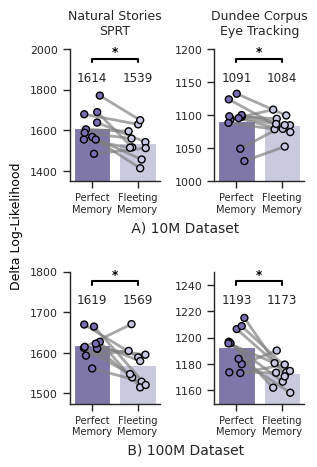

In [12]:
#Figure 5 - Reading Time Analysis - Natural Stories SPRT, Dundee Corpus Eye Tracking
with silence_prints():
        
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')

            
        fig_5_data = run_data_unfiltered[(run_data_unfiltered["curriculum_learning"]==False) &
                                        (run_data_unfiltered["batch_size"]==32) &
                                        (run_data_unfiltered["num_iterations"]==44000) &
                                        (run_data_unfiltered["n_layer"]==6) &
                                        (run_data_unfiltered["dataset"].isin(["babylm_full_bpe_8k", "babylm_full_bpe_100M_8k"])) &
                                        
                                        (
                                            (
                                                (run_data_unfiltered["echoic_memory"].isin([10]) & (run_data_unfiltered["mask_decay_rate"].isin([2]))) & (run_data_unfiltered["mask_type"].isin(["exponential_new"]))
                                            ) |
                                                (run_data_unfiltered["mask_type"].isin(["Non"]))
                                        )
                                    
                                        ][["run_id", "output_folder_name", "mask_type", "mask_decay_rate", "echoic_memory", "seed", "dataset"]].assign(mask_type=lambda x: pd.Categorical(x["mask_type"], categories=["Non", "exponential_new"], ordered=True)).sort_values(by=["mask_type", "mask_decay_rate"])
                                                
        fig_5_data = fig_5_data[~fig_5_data["run_id"].isin([5734459, 5496427, 6617787, 8456913])]


        fig_5_data = fig_5_data.merge(reading_time_fit_df_osh[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_osh_sprt"), how="left", left_on="run_id", right_on="ModelID_osh_sprt",).drop(columns=["ModelID_osh_sprt"])
        fig_5_data["delta_log_likelihood_avg_osh"] = fig_5_data["Delta Log-Likelihood_osh_sprt"] / fig_5_data["Data Size_osh_sprt"]

        #Join to get Dundee Corpus Data too
        fig_5_data = fig_5_data.merge(reading_time_fit_df_osh_dundee[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_osh_dundee"), how="left", left_on="run_id", right_on="ModelID_osh_dundee",).drop(columns=["ModelID_osh_dundee"])
        fig_5_data["delta_log_likelihood_avg_dundee"] = fig_5_data["Delta Log-Likelihood_osh_dundee"] / fig_5_data["Data Size_osh_dundee"]


        fig_5_data["condition"] = (fig_5_data["mask_type"].astype(str).replace({"Non": "nomask", "exponential_new": "ee"}) + fig_5_data["mask_decay_rate"].astype(int).astype(str).str.zfill(3).replace("000","") + "_EM" + fig_5_data["echoic_memory"].astype(str).str.zfill(2))

        condition_triplet_map = {"nomask_EM01": "Perfect\nMemory",
                                "ee002_EM10": "Fleeting\nMemory"}

        fig_5_data["condition"] = pd.Categorical(fig_5_data["condition"], categories=["nomask_EM01", "ee002_EM10"], ordered=True)
        fig_5_data = fig_5_data.sort_values(by=["dataset", "condition", "seed"])

        fig_5_data["condition"] = fig_5_data["condition"].map(condition_triplet_map)

        fig_5_data["dataset"] = fig_5_data["dataset"].replace({"babylm_full_bpe_8k": "10M", "babylm_full_bpe_100M_8k": "100M"})
        fig_5_data = fig_5_data.reset_index(drop=True)
        #print(fig_5_data.groupby(["dataset", "mask_type", "mask_decay_rate", "echoic_memory"]).size())


        with sns.axes_style("ticks"), sns.plotting_context("paper", font_scale=.9):
            
            #fig, ax = plt.subplots(1, 2)
            #fig.set_size_inches(8, 4)
            #subfigs = plt.figure(figsize=(6, 8)).subfigures(nrows=2, ncols=1)
            fig = plt.figure(figsize=(single_col_width, 2*single_col_height))
            subfigs = fig.subfigures(nrows=2, ncols=1, hspace=0.3)
            for i, dataset in enumerate(["10M", "100M"]):
                ax = subfigs[i].subplots(1, 2)
                #subfigs[i].suptitle(f"Effect of Masking on Reading Time Analysis ({dataset})", y = 1.0)

                letter_char = "A" if i == 0 else "B"
                subfigs[i].suptitle(f" {letter_char}) {dataset} Dataset", y = -0.12, fontsize=10)
                for j, rt_fit in enumerate(["Delta Log-Likelihood_osh_sprt", "Delta Log-Likelihood_osh_dundee"]):
                        
                    fig_5_data_subset = fig_5_data[fig_5_data["dataset"] == dataset].reset_index(drop=True)
                    #print("H1", fig_5_data_subset.shape)
                    #axr = ax[i]
                    axr = ax[j]
                    # sns.barplot(data=fig_5_data_subset, x="condition", y="Delta Log-Likelihood_osh_sprt", hue = "condition",
                    #             ax=axr, palette = "Purples_r", errorbar=None)
                    # sns.stripplot(data=fig_5_data_subset, x="condition", y="Delta Log-Likelihood_osh_sprt", hue = "condition", 
                    #             ax=axr, palette = "Purples_r", edgecolor='k', linewidth=0.35)
                    sns.barplot(data=fig_5_data_subset, x="condition", y=rt_fit, hue = "condition", ax=axr, palette = "Purples_r", errorbar=None)
                    sns.stripplot(data=fig_5_data_subset, x="condition", y=rt_fit, hue = "condition", ax=axr, palette = "Purples_r", edgecolor='black', alpha=1, jitter=0.2, linewidth=1)
                    if j == 0:
                        if dataset == "10M":
                            axr.set_ylim(1350, 2000)
                        else:
                            axr.set_ylim(1475, 1800)
                        
                    else:
                        if dataset == "10M":
                            axr.set_ylim(1000, 1200)
                        else:
                            axr.set_ylim(1150, 1250)
                    #print(fig_5_data_subset.shape, i)
                    #print(fig_5_data_subset)
                    connect_dots(axr, alpha=.7)
                    res = annotate_given_colid(axr, 1, 0, fig_5_data_subset, 0.45, 0.02, "Delta Log-Likelihood_osh_sprt", h_factor=0.9)
                    # axr.set_ylabel("Delta Log-Likelihood")
                    # if i == 1:
                    #     axr.set_ylabel("")
                    axr.set_ylabel("")
                    axr.set_xlabel("")
                    axr.set_xticklabels(axr.get_xticklabels(), size=axr.xaxis.get_ticklabels()[0].get_fontsize()*0.9)

                    #Set patch height as x percent of y lim max - y lim min
                    patch_height = (axr.get_ylim()[1] - axr.get_ylim()[0]) * 0.68 + axr.get_ylim()[0]
                    #print(patch_height)
                    
                    for p in axr.patches:
                        axr.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., patch_height ), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
                        #p.get_height()+0.015
                if i == 0:
                        
                    for n, axs in enumerate(ax.flat):
                        if n == 0:
                            sns.despine(ax=axs)
                            axs.set_title("Natural Stories\nSPRT", y = 1.05, fontsize=9)
                        else:
                            sns.despine(ax=axs)
                            axs.set_title("Dundee Corpus\nEye Tracking", y = 1.05, fontsize=9)
                            
                else:
                    for n, axs in enumerate(ax.flat):
                        if n == 0:
                            sns.despine(ax=axs)
                        else:
                            sns.despine(ax=axs)
        
        plt.subplots_adjust(wspace=0.6)
        fig.supylabel("Delta Log-Likelihood", x=-0.05, ha='center', fontsize=9, fontweight='normal')
        
        save_matplot_fig(fig, "Figure_5_v2.pdf", dpi=3000)

# Additional Figures Below ()

- Separate BLIMP Subtasks (Can be added as table too)
- Individual Figures for all setups (If Needed)
- Pairwise validation Loss Matrix (5 decay rates, 3 echoic memory values 5x3 matrix)


<pre>































</pre>



NOTE: Not all of the below code blocks work correctly in the current version, however, most are appendix stuff, so will update if necessary later

/tmp/ipykernel_232696/3919971082.py:314: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby('seed').apply(lambda x: x[x['condition']==list(conditional_map.values())[1]]["score"].values[0] - x[x['condition']==list(conditional_map.values())[0]]["score"].values[0])
/tmp/ipykernel_232696/3773833047.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([blimp_name_map[i.get_text()] for i in ax.get_xticklabels()])
/tmp/ipykernel_232696/3919971082.py:314: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in

Figure not saved


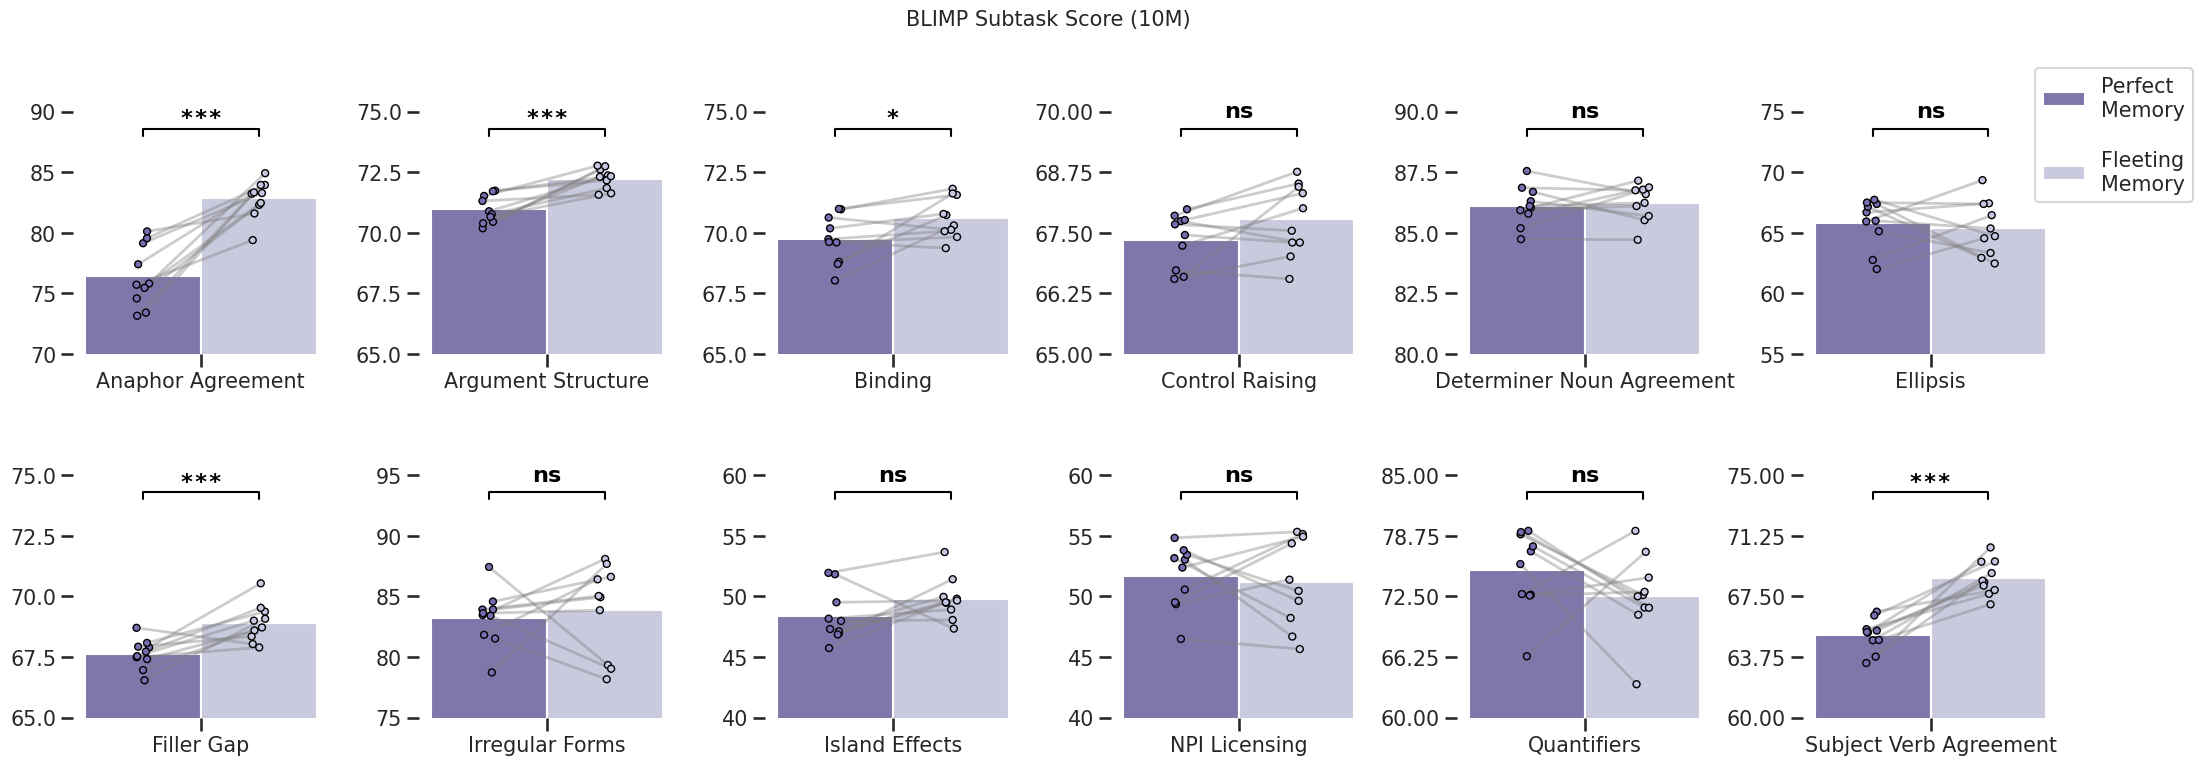

In [13]:

#Group by condition and get average of all BLIMP_avg and sort by that value

supplement_individual_blimp_df = run_data_unfiltered[(run_data_unfiltered["curriculum_learning"]==False) &
                                (run_data_unfiltered["batch_size"]==32) &
                                (run_data_unfiltered["num_iterations"]==44000) &
                                (run_data_unfiltered["n_layer"]==6) &
                                (run_data_unfiltered["dataset"].isin(["babylm_full_bpe_8k", "babylm_full_bpe_100M_8k"])) &
                                
                                (
                                    (
                                        (run_data_unfiltered["echoic_memory"].isin([10]) & (run_data_unfiltered["mask_decay_rate"].isin([2]))) & (run_data_unfiltered["mask_type"].isin(["exponential_new"]))
                                    ) |
                                        (run_data_unfiltered["mask_type"].isin(["Non"]))
                                )
                            
                                ][["run_id", "output_folder_name", "mask_type", "mask_decay_rate", "echoic_memory", "seed", "dataset"]].assign(mask_type=lambda x: pd.Categorical(x["mask_type"], categories=["Non", "exponential_new"], ordered=True)).sort_values(by=["mask_type", "mask_decay_rate"])
                                        

supplement_individual_blimp_df = supplement_individual_blimp_df.merge(blimp_data, on="run_id", how="left")
supplement_individual_blimp_df = supplement_individual_blimp_df[~supplement_individual_blimp_df["run_id"].isin([5734459, 5496427, 6617787, 8465077])]

#print(fig_4_data.groupby(["dataset", "mask_type", "mask_decay_rate", "echoic_memory"]).size())

#fig_4_data
supplement_individual_blimp_df["condition"] = (supplement_individual_blimp_df["mask_type"].astype(str).replace({"Non": "nomask", "exponential_new": "ee"}) + supplement_individual_blimp_df["mask_decay_rate"].astype(int).astype(str).str.zfill(3).replace("000","") + "_EM" + supplement_individual_blimp_df["echoic_memory"].astype(str).str.zfill(2))

condition_triplet_map = {"nomask_EM01": "Perfect\nMemory",
                        "ee002_EM10": "Fleeting\nMemory"}

supplement_individual_blimp_df["condition"] = pd.Categorical(supplement_individual_blimp_df["condition"], categories=["nomask_EM01", "ee002_EM10"], ordered=True)
seed_df_blimp_indv = supplement_individual_blimp_df.sort_values(by=["dataset", "condition", "seed"])

#seed_df_blimp_indv["condition"] = seed_df_blimp_indv["condition"].map(condition_triplet_map)

supplement_individual_blimp_df["dataset"] = supplement_individual_blimp_df["dataset"].replace({"babylm_full_bpe_8k": "10M", "babylm_full_bpe_100M_8k": "100M"})

seed_df_blimp_indv_10M = supplement_individual_blimp_df[supplement_individual_blimp_df["dataset"] == "10M"]


#For this condition pair, plot all BLIMP tasks
#conditional_map = {"nomask_EM01": "No Mask", "ee002_EM10": "Exponential Mask\nEM10"}
#rcParams.update(params_two_col)
with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    fig, axs = plt.subplots(2, 6)
    fig.set_size_inches(21, 7)
    fig.tight_layout()
    fig.subplots_adjust(hspace=0.5)
    blimp_subtask_stats_test = []
    for row, ax1 in enumerate(axs):
        #Split blimp categories into 2 rows of subplots
        if row == 0:
            data_columns = [i[0] for i in blimp_categories[:6]] 
        else:
            data_columns = [i[0] for i in blimp_categories[6:12]]
        for col, ax2 in enumerate(ax1):
                
            ax = ax2
            data_column = [data_columns[col]] + ["condition", "seed"]
            plot_data = seed_df_blimp_indv_10M[data_column][seed_df_blimp_indv_10M["condition"].isin(["nomask_EM01", "ee002_EM10"])]
            plot_data["condition"] = pd.Categorical(plot_data["condition"], categories=["nomask_EM01", "ee002_EM10"], ordered=True)
            plot_data["condition"] = plot_data["condition"].map(condition_triplet_map)
            
            #Pivot blimp_categories into rows 
            plot_data = pd.melt(plot_data, id_vars=["condition", "seed"], value_vars=[k for k in data_column[:-2]                                                                                ]).rename(columns={"variable": "blimp_task", "value": "score"})
            
            sns.barplot(data=plot_data, x="blimp_task", y="score" , hue="condition",
                        dodge=True, ax=ax, errorbar=None, palette="Purples_r")
            
            #Add value labels to each bar slighly above the bar
            
            # for p in ax.patches:
            #     ax.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height()+3.5),
            #                 ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
            
            sns.stripplot(data=plot_data, x="blimp_task", y="score", hue="condition", dodge=True, jitter=0.05, ax=ax, alpha=1, edgecolor='black', linewidth=1, palette="Purples_r")
            connect_dots_ib(ax)
            
            #set title for each subplot but remove \n from mapping
            #ax.xaxis.set_tick_params(rotation=45)
            #ax.set_ylim(40, 125)

            #Set dynamic y limit based on the data
            #Get maximum and minimum y values
            dist = 5 if plot_data["score"].std() > 1 else 3
            y_max = int(round((plot_data["score"].max() + dist) / 5) * 5)
            y_min = int(round((plot_data["score"].min() - dist) / 5) * 5)

            
            ax.set_ylim(y_min, y_max)

            #Set only 5 ticks on y axis
            ax.set_yticks(np.linspace(y_min, y_max, 5))
            # ax.set_yticks(ax.get_yticks()[ax.get_yticks() <= 100])
            
            #Remove legend for each subplot
            ax.get_legend().remove()
            ax.set_xlabel("")
            ax.set_ylabel("")
            
            res = annotate_given_colid_ib(ax, 0, plot_data, 0.9, 0.03, 
                                          {x: condition_triplet_map[x] for x in ["nomask_EM01", "ee002_EM10"]})
            blimp_subtask_stats_test.append({**{"blimp_task": blimp_name_map[data_columns[0]],
                                                "pair_A":"nomask_EM01", "pair_B":"ee002_EM10"} , **res})
        
        #supplement_individual_blimp_df
        #print(ax.get_xticklabels())
        
            ax.set_xticklabels([blimp_name_map[i.get_text()] for i in ax.get_xticklabels()])
            sns.despine(bottom=True, left=True, ax=ax)

    handles, labels = ax.get_legend_handles_labels()
    #Legend position is set to top right and overlapping with the plot
    fig.legend(handles[:2], labels[:2], loc='right', bbox_to_anchor=(1.05, 0.92), labelspacing=1.5)
    #fig.supylabel("BLIMP Score")
    #print(pd.DataFrame(blimp_subtask_stats_test))


    fig.suptitle("BLIMP Subtask Score (10M)", y = 1.1, fontsize=15)

    # save_matplot_fig(fig, "Fig9_blimp_subtask_10M.png", dpi=1000)
    save_matplot_fig(fig, "Fig_supplement_blimp_subtask_10M.pdf", dpi=3000)


100 75 5 3.377110217193507 95.3476482617587 82.2597137014315


/tmp/ipykernel_232696/3919971082.py:314: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby('seed').apply(lambda x: x[x['condition']==list(conditional_map.values())[1]]["score"].values[0] - x[x['condition']==list(conditional_map.values())[0]]["score"].values[0])
/tmp/ipykernel_232696/835881666.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([blimp_name_map[i.get_text()] for i in ax.get_xticklabels()])


80 70 3.5 0.8910836646219908 76.8428709990301 73.3996120271581


/tmp/ipykernel_232696/3919971082.py:314: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby('seed').apply(lambda x: x[x['condition']==list(conditional_map.values())[1]]["score"].values[0] - x[x['condition']==list(conditional_map.values())[0]]["score"].values[0])
/tmp/ipykernel_232696/835881666.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([blimp_name_map[i.get_text()] for i in ax.get_xticklabels()])


80 65 3.5 0.9937162981737889 74.4582962303354 70.4660136539032


...

60 40 5 2.591287566669261 55.6053811659193 46.7488789237668
60 30 5 7.156734367891173 57.4552080170058 33.5863953841482


/tmp/ipykernel_232696/3919971082.py:314: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby('seed').apply(lambda x: x[x['condition']==list(conditional_map.values())[1]]["score"].values[0] - x[x['condition']==list(conditional_map.values())[0]]["score"].values[0])
/tmp/ipykernel_232696/835881666.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([blimp_name_map[i.get_text()] for i in ax.get_xticklabels()])
/tmp/ipykernel_232696/3919971082.py:314: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a

90 60 5 6.5838242569008205 86.1411643482741 63.57547655847501


/tmp/ipykernel_232696/3919971082.py:314: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby('seed').apply(lambda x: x[x['condition']==list(conditional_map.values())[1]]["score"].values[0] - x[x['condition']==list(conditional_map.values())[0]]["score"].values[0])
/tmp/ipykernel_232696/835881666.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([blimp_name_map[i.get_text()] for i in ax.get_xticklabels()])
/tmp/ipykernel_232696/3919971082.py:314: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a

85 60 5 3.074505261033373 78.5185185185185 66.7570009033424
Figure not saved


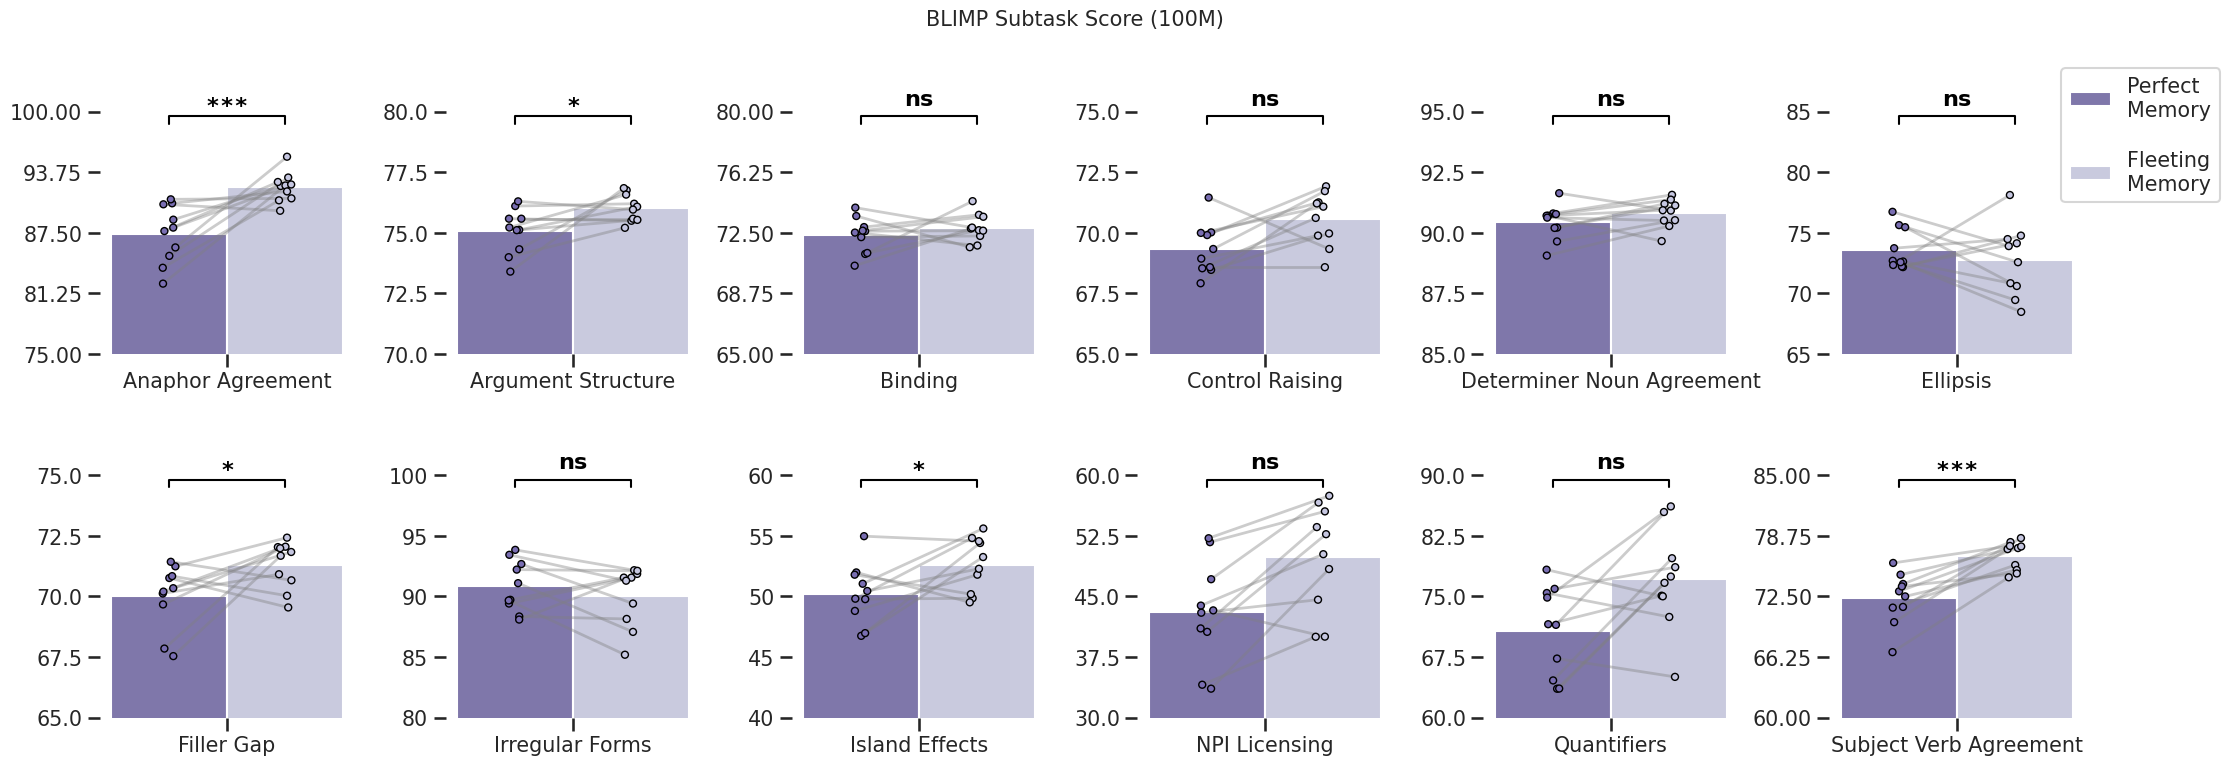

In [14]:
seed_df_blimp_indv_100M = supplement_individual_blimp_df[supplement_individual_blimp_df["dataset"] == "100M"]


#For this condition pair, plot all BLIMP tasks
#conditional_map = {"nomask_EM01": "No Mask", "ee002_EM10": "Exponential Mask\nEM10"}
#rcParams.update(params_two_col)

with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    fig, axs = plt.subplots(2, 6)
    fig.set_size_inches(21, 7)
    fig.tight_layout()
    fig.subplots_adjust(hspace=0.5)
    blimp_subtask_stats_test = []
    for row, ax1 in enumerate(axs):
        #Split blimp categories into 2 rows of subplots
        if row == 0:
            data_columns = [i[0] for i in blimp_categories[:6]] 
        else:
            data_columns = [i[0] for i in blimp_categories[6:12]]
        for col, ax2 in enumerate(ax1):
                
            ax = ax2
            data_column = [data_columns[col]] + ["condition", "seed"]
            plot_data = seed_df_blimp_indv_100M[data_column][seed_df_blimp_indv_100M["condition"].isin(["nomask_EM01", "ee002_EM10"])]
            plot_data["condition"] = pd.Categorical(plot_data["condition"], categories=["nomask_EM01", "ee002_EM10"], ordered=True)
            plot_data["condition"] = plot_data["condition"].map(condition_triplet_map)
            
            #Pivot blimp_categories into rows 
            plot_data = pd.melt(plot_data, id_vars=["condition", "seed"], value_vars=[k for k in data_column[:-2]                                                                                ]).rename(columns={"variable": "blimp_task", "value": "score"})
            
            sns.barplot(data=plot_data, x="blimp_task", y="score" , hue="condition",
                        dodge=True, ax=ax, errorbar=None, palette="Purples_r")
            
            #Add value labels to each bar slighly above the bar
            
            # for p in ax.patches:
            #     ax.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height()+3.5),
            #                 ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
            
            sns.stripplot(data=plot_data, x="blimp_task", y="score", hue="condition", dodge=True, jitter=0.05, ax=ax, alpha=1, edgecolor='black', linewidth=1, palette="Purples_r")
            connect_dots_ib(ax)
            
            #set title for each subplot but remove \n from mapping
            #ax.xaxis.set_tick_params(rotation=45)
            #ax.set_ylim(40, 125)

            #Set dynamic y limit based on the data
            #Get maximum and minimum y values
            dist = 5 if plot_data["score"].std() > 1 else 3.5
            y_max = int(round((plot_data["score"].max() + dist) / 5) * 5)
            y_min = int(round((plot_data["score"].min() - dist) / 5) * 5)
            print(y_max, y_min, dist, plot_data["score"].std(), plot_data["score"].max(), plot_data["score"].min())
            
            ax.set_ylim(y_min, y_max)

            #Set only 5 ticks on y axis
            ax.set_yticks(np.linspace(y_min, y_max, 5))
            # ax.set_yticks(ax.get_yticks()[ax.get_yticks() <= 100])
            
            #Remove legend for each subplot
            ax.get_legend().remove()
            ax.set_xlabel("")
            ax.set_ylabel("")
            
            res = annotate_given_colid_ib(ax, 0, plot_data, 0.95, 0.03, 
                                          {x: condition_triplet_map[x] for x in ["nomask_EM01", "ee002_EM10"]})
            blimp_subtask_stats_test.append({**{"blimp_task": blimp_name_map[data_columns[0]],
                                                "pair_A":"nomask_EM01", "pair_B":"ee002_EM10"} , **res})
        
        #supplement_individual_blimp_df
        #print(ax.get_xticklabels())
        
            ax.set_xticklabels([blimp_name_map[i.get_text()] for i in ax.get_xticklabels()])
            sns.despine(bottom=True, left=True, ax=ax)

    handles, labels = ax.get_legend_handles_labels()
    #Legend position is set to top right and overlapping with the plot
    fig.legend(handles[:2], labels[:2], loc='right', bbox_to_anchor=(1.05, 0.92), labelspacing=1.5)
    #fig.supylabel("BLIMP Score")
    #print(pd.DataFrame(blimp_subtask_stats_test))


    fig.suptitle("BLIMP Subtask Score (100M)", y = 1.1, fontsize=15)

    # save_matplot_fig(fig, "Fig9_blimp_subtask_10M.png", dpi=1000)
    save_matplot_fig(fig, "Fig_supplement_blimp_subtask_100M.pdf", dpi=3000)


## BLIMP Subtasks individual charts - 10M

/tmp/ipykernel_232696/3919971082.py:314: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby('seed').apply(lambda x: x[x['condition']==list(conditional_map.values())[1]]["score"].values[0] - x[x['condition']==list(conditional_map.values())[0]]["score"].values[0])
/tmp/ipykernel_232696/187789252.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([blimp_name_map[i.get_text()] for i in ax.get_xticklabels()])
/tmp/ipykernel_232696/3919971082.py:314: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a

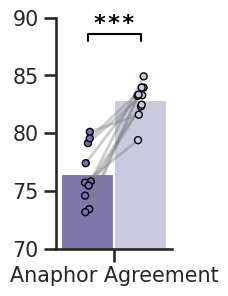

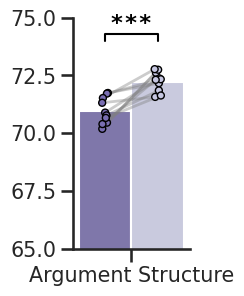

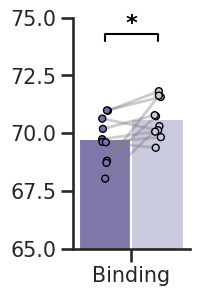

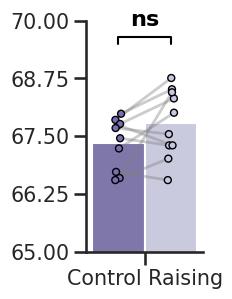

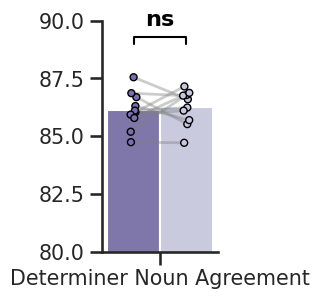

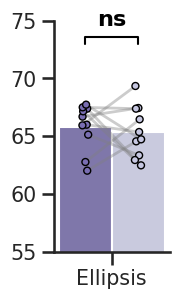

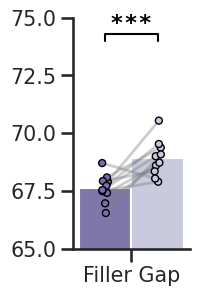

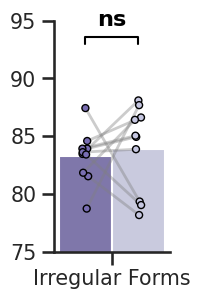

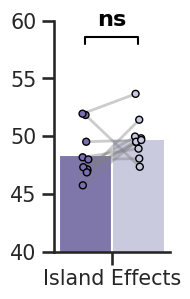

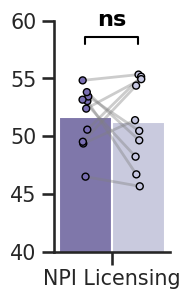

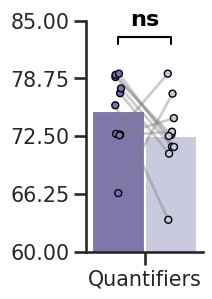

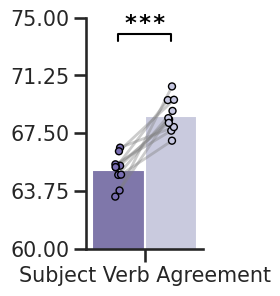

In [16]:
seed_df_blimp_indv_10M = supplement_individual_blimp_df[supplement_individual_blimp_df["dataset"] == "10M"]


#For this condition pair, plot all BLIMP tasks
#conditional_map = {"nomask_EM01": "No Mask", "ee002_EM10": "Exponential Mask\nEM10"}
#rcParams.update(params_two_col)
with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    #fig, axs = plt.subplots(1, 1)
    # fig.set_size_inches(21, 7)
    # fig.tight_layout()
    # fig.subplots_adjust(hspace=0.5)
    blimp_subtask_stats_test = []
    for col, blimp_cat in enumerate(blimp_categories):

        #Split blimp categories into 2 rows of subplots
        if blimp_cat[1] != "blimp":
            continue
        fig, ax = plt.subplots(1, 1, figsize=(1.5, 3))
        #data_column = [data_columns[col]] + ["condition", "seed"]
        data_column = [blimp_cat[0]] + ["condition", "seed"]

        plot_data = seed_df_blimp_indv_10M[data_column][seed_df_blimp_indv_10M["condition"].isin(["nomask_EM01", "ee002_EM10"])]
        plot_data["condition"] = pd.Categorical(plot_data["condition"], categories=["nomask_EM01", "ee002_EM10"], ordered=True)
        plot_data["condition"] = plot_data["condition"].map(condition_triplet_map)
        
        #Pivot blimp_categories into rows 
        plot_data = pd.melt(plot_data, id_vars=["condition", "seed"], value_vars=[k for k in data_column[:-2]                                                                                ]).rename(columns={"variable": "blimp_task", "value": "score"})
        
        sns.barplot(data=plot_data, x="blimp_task", y="score" , hue="condition",
                    dodge=True, ax=ax, errorbar=None, palette="Purples_r")
        
        #Add value labels to each bar slighly above the bar
        
        # for p in ax.patches:
        #     ax.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height()+3.5),
        #                 ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
        
        sns.stripplot(data=plot_data, x="blimp_task", y="score", hue="condition", dodge=True, jitter=0.05, ax=ax, alpha=1, edgecolor='black', linewidth=1, palette="Purples_r")
        connect_dots_ib(ax)
        
        #set title for each subplot but remove \n from mapping
        #ax.xaxis.set_tick_params(rotation=45)
        #ax.set_ylim(40, 125)

        #Set dynamic y limit based on the data
        #Get maximum and minimum y values
        dist = 5 if plot_data["score"].std() > 1 else 3
        y_max = int(round((plot_data["score"].max() + dist) / 5) * 5)
        y_min = int(round((plot_data["score"].min() - dist) / 5) * 5)

        
        ax.set_ylim(y_min, y_max)

        #Set only 5 ticks on y axis
        ax.set_yticks(np.linspace(y_min, y_max, 5))
        # ax.set_yticks(ax.get_yticks()[ax.get_yticks() <= 100])
        
        #Remove legend for each subplot
        ax.get_legend().remove()
        ax.set_xlabel("")
        ax.set_ylabel("")
        
        res = annotate_given_colid_ib(ax, 0, plot_data, 0.9, 0.03, 
                                        {x: condition_triplet_map[x] for x in ["nomask_EM01", "ee002_EM10"]})
        blimp_subtask_stats_test.append({**{"blimp_task": blimp_name_map[data_columns[0]],
                                            "pair_A":"nomask_EM01", "pair_B":"ee002_EM10"} , **res})
    
    #supplement_individual_blimp_df
    #print(ax.get_xticklabels())
    
        ax.set_xticklabels([blimp_name_map[i.get_text()] for i in ax.get_xticklabels()])
        sns.despine()

    handles, labels = ax.get_legend_handles_labels()
    #Legend position is set to top right and overlapping with the plot
    #fig.legend(handles[:2], labels[:2], loc='right', bbox_to_anchor=(1.05, 0.92), labelspacing=1.5)
    #fig.supylabel("BLIMP Score")
    #print(pd.DataFrame(blimp_subtask_stats_test))


    #fig.suptitle("BLIMP Subtask Score (10M)", y = 1.1, fontsize=15)
 
    # save_matplot_fig(fig, "Fig9_blimp_subtask_10M.png", dpi=1000)
    #save_matplot_fig(fig, "Fig_supplement_blimp_subtask_10M.pdf", dpi=3000)


## BLIMP Subtasks individual charts - 100M

/tmp/ipykernel_232696/3919971082.py:314: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby('seed').apply(lambda x: x[x['condition']==list(conditional_map.values())[1]]["score"].values[0] - x[x['condition']==list(conditional_map.values())[0]]["score"].values[0])
/tmp/ipykernel_232696/1638969377.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([blimp_name_map[i.get_text()] for i in ax.get_xticklabels()])
/tmp/ipykernel_232696/3919971082.py:314: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in 

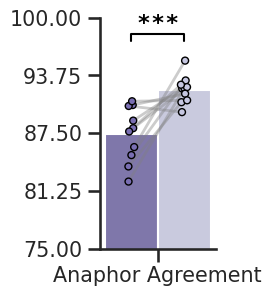

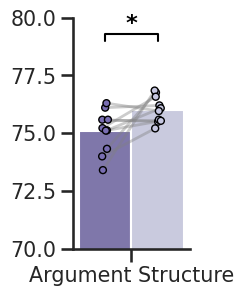

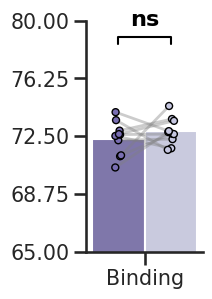

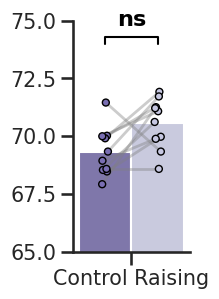

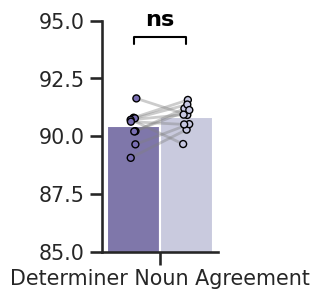

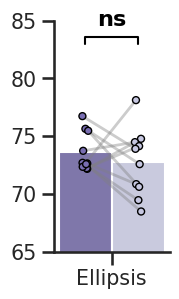

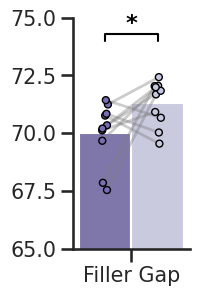

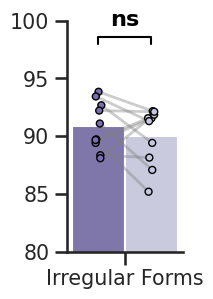

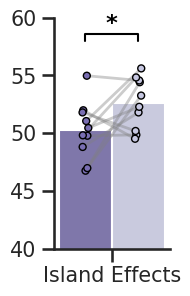

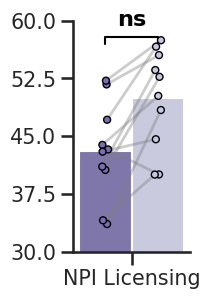

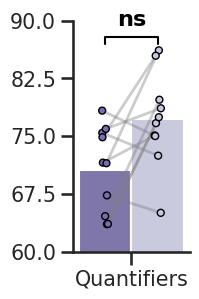

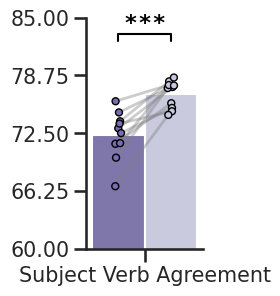

In [17]:

#For this condition pair, plot all BLIMP tasks
#conditional_map = {"nomask_EM01": "No Mask", "ee002_EM10": "Exponential Mask\nEM10"}
#rcParams.update(params_two_col)
with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):

    blimp_subtask_stats_test = []
    for col, blimp_cat in enumerate(blimp_categories):

        #Split blimp categories into 2 rows of subplots
        if blimp_cat[1] != "blimp":
            continue
        fig, ax = plt.subplots(1, 1, figsize=(1.5, 3))
        #data_column = [data_columns[col]] + ["condition", "seed"]
        data_column = [blimp_cat[0]] + ["condition", "seed"]

        plot_data = seed_df_blimp_indv_100M[data_column][seed_df_blimp_indv_100M["condition"].isin(["nomask_EM01", "ee002_EM10"])]
        plot_data["condition"] = pd.Categorical(plot_data["condition"], categories=["nomask_EM01", "ee002_EM10"], ordered=True)
        plot_data["condition"] = plot_data["condition"].map(condition_triplet_map)
        
        #Pivot blimp_categories into rows 
        plot_data = pd.melt(plot_data, id_vars=["condition", "seed"], value_vars=[k for k in data_column[:-2]                                                                                ]).rename(columns={"variable": "blimp_task", "value": "score"})
        
        sns.barplot(data=plot_data, x="blimp_task", y="score" , hue="condition",
                    dodge=True, ax=ax, errorbar=None, palette="Purples_r")
        
        #Add value labels to each bar slighly above the bar
        
        # for p in ax.patches:
        #     ax.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height()+3.5),
        #                 ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
        
        sns.stripplot(data=plot_data, x="blimp_task", y="score", hue="condition", dodge=True, jitter=0.05, ax=ax, alpha=1, edgecolor='black', linewidth=1, palette="Purples_r")
        connect_dots_ib(ax)
        
        #set title for each subplot but remove \n from mapping
        #ax.xaxis.set_tick_params(rotation=45)
        #ax.set_ylim(40, 125)

        #Set dynamic y limit based on the data
        #Get maximum and minimum y values
        dist = 5 if plot_data["score"].std() > 1 else 3.5
        y_max = int(round((plot_data["score"].max() + dist) / 5) * 5)
        y_min = int(round((plot_data["score"].min() - dist) / 5) * 5)

        
        ax.set_ylim(y_min, y_max)

        #Set only 5 ticks on y axis
        ax.set_yticks(np.linspace(y_min, y_max, 5))
        # ax.set_yticks(ax.get_yticks()[ax.get_yticks() <= 100])
        
        #Remove legend for each subplot
        ax.get_legend().remove()
        ax.set_xlabel("")
        ax.set_ylabel("")
        
        res = annotate_given_colid_ib(ax, 0, plot_data, 0.9, 0.03, 
                                        {x: condition_triplet_map[x] for x in ["nomask_EM01", "ee002_EM10"]})
        blimp_subtask_stats_test.append({**{"blimp_task": blimp_name_map[data_columns[0]],
                                            "pair_A":"nomask_EM01", "pair_B":"ee002_EM10"} , **res})
    
    #supplement_individual_blimp_df
    #print(ax.get_xticklabels())
    
        ax.set_xticklabels([blimp_name_map[i.get_text()] for i in ax.get_xticklabels()])
        sns.despine()

    handles, labels = ax.get_legend_handles_labels()
    #Legend position is set to top right and overlapping with the plot
    #fig.legend(handles[:2], labels[:2], loc='right', bbox_to_anchor=(1.05, 0.92), labelspacing=1.5)
    #fig.supylabel("BLIMP Score")
    #print(pd.DataFrame(blimp_subtask_stats_test))


    #fig.suptitle("BLIMP Subtask Score (10M)", y = 1.1, fontsize=15)
 
    # save_matplot_fig(fig, "Fig9_blimp_subtask_10M.png", dpi=1000)
    #save_matplot_fig(fig, "Fig_supplement_blimp_subtask_10M.pdf", dpi=3000)


In [18]:
#Since only 5 seed values are there for all different settings - 42, 466, 616, 1337, 2347

seed_df_masks_10M = run_data_unfiltered[
    (run_data_unfiltered["curriculum_learning"] == False) & (run_data_unfiltered["dataset"] == "babylm_full_bpe_8k") & 
    (run_data_unfiltered["n_layer"] == 6) & (run_data_unfiltered["batch_size"] == 32) & (run_data_unfiltered["num_iterations"] == 44000) & (run_data_unfiltered["seed"].isin([42, 466, 616, 1337, 2347]))
    & (((run_data_unfiltered["mask_type"].isin(["Non"]))  & (run_data_unfiltered["run_id"] != 5496427)) 
        | ((run_data_unfiltered["mask_type"].isin(["exponential_new"])) & (run_data_unfiltered["mask_decay_rate"].isin([0.5,1,2,3,4])) & (run_data_unfiltered["echoic_memory"].isin([1,5,10]))))
][["run_id", "output_folder_name", "n_layer", "n_head", "block_size", "n_embd", "batch_size", "learning_rate", "mask_type", "mask_decay_rate", "echoic_memory", "dataset", "seed"]].reset_index(drop=True)


seed_df_masks_10M = seed_df_masks_10M.sort_values(by=["mask_type", "mask_decay_rate", "echoic_memory", "seed"]).reset_index(drop=True)

seed_df_masks_10M["condition"] = seed_df_masks_10M["mask_type"].apply(lambda x: "Mask" if x != "Non" else "No\nMask")
seed_df_masks_10M["x_condition"] = seed_df_masks_10M["condition"] + " " + seed_df_masks_10M["mask_decay_rate"].astype(str).apply(lambda x: "" if x == "0.0" else x) 
seed_df_masks_10M["x_condition"] = seed_df_masks_10M["x_condition"].apply(lambda x: x.strip())

seed_df_masks_10M["condition"] = seed_df_masks_10M["condition"] + "\nEM" + seed_df_masks_10M["echoic_memory"].astype(str).str.zfill(2)
seed_df_masks_10M = seed_df_masks_10M.sort_values(by=["seed", "condition"]).reset_index(drop=True)

seed_df_masks_10M = seed_df_masks_10M.merge(loss_data[['run_id', 'val_loss', 'train_loss']], on="run_id", how="left")


seed_df_masks_10M["echoic_memory_flag"] = seed_df_masks_10M["echoic_memory"].apply(lambda x: False if x == 1 else True)

seed_df_masks_10M.sort_values(by=['x_condition', 'echoic_memory', 'seed'], inplace=True)

seed_df_masks_10M

,run_id,output_folder_name,n_layer,n_head,block_size,n_embd,batch_size,learning_rate,mask_type,mask_decay_rate,echoic_memory,dataset,seed,condition,x_condition,val_loss,train_loss,echoic_memory_flag
0,7678419,out-babylm_full_bpe_8k-6x6-mask_ee0p5_em01-767...,6,6,256,384,32.0,0.0005,exponential_new,0.5,1,babylm_full_bpe_8k,42,Mask\nEM01,Mask 0.5,3.849141,2.902341,False
16,7678422,out-babylm_full_bpe_8k-6x6-mask_ee0p5_em01-767...,6,6,256,384,32.0,0.0005,exponential_new,0.5,1,babylm_full_bpe_8k,466,Mask\nEM01,Mask 0.5,3.852789,2.902600,False
32,7678421,out-babylm_full_bpe_8k-6x6-mask_ee0p5_em01-767...,6,6,256,384,32.0,0.0005,exponential_new,0.5,1,babylm_full_bpe_8k,616,Mask\nEM01,Mask 0.5,3.844611,2.897148,False
48,6810321,out-babylm_full_bpe_8k-6x6-mask_ee0p5_em01-681...,6,6,256,384,32.0,0.0005,exponential_new,0.5,1,babylm_full_bpe_8k,1337,Mask\nEM01,Mask 0.5,3.851278,2.890961,False
64,7678420,out-babylm_full_bpe_8k-6x6-mask_ee0p5_em01-767...,6,6,256,384,32.0,0.0005,exponential_new,0.5,1,babylm_full_bpe_8k,2347,Mask\nEM01,Mask 0.5,3.842221,2.896809,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,6892212,out-babylm_full_bpe_8k-6x6-nomask-6892212_s42,6,6,256,384,32.0,0.0005,Non,0.0,1,babylm_full_bpe_8k,42,No\nMask\nEM01,No\nMask,3.851849,2.912897,False
31,6892220,out-babylm_full_bpe_8k-6x6-nomask-6892220_s466,6,6,256,384,32.0,0.0005,Non,0.0,1,babylm_full_bpe_8k,466,No\nMask\nEM01,No\nMask,3.857377,2.915270,False
47,6892216,out-babylm_full_bpe_8k-6x6-nomask-6892216_s616,6,6,256,384,32.0,0.0005,Non,0.0,1,babylm_full_bpe_8k,616,No\nMask\nEM01,No\nMask,3.837300,2.907289,False
63,6892222,out-babylm_full_bpe_8k-6x6-nomask-6892222_s1337,6,6,256,384,32.0,0.0005,Non,0.0,1,babylm_full_bpe_8k,1337,No\nMask\nEM01,No\nMask,3.845519,2.897251,False


3
5
[ 1  5 10]
['Mask 0.5' 'Mask 1.0' 'Mask 2.0' 'Mask 3.0' 'Mask 4.0']


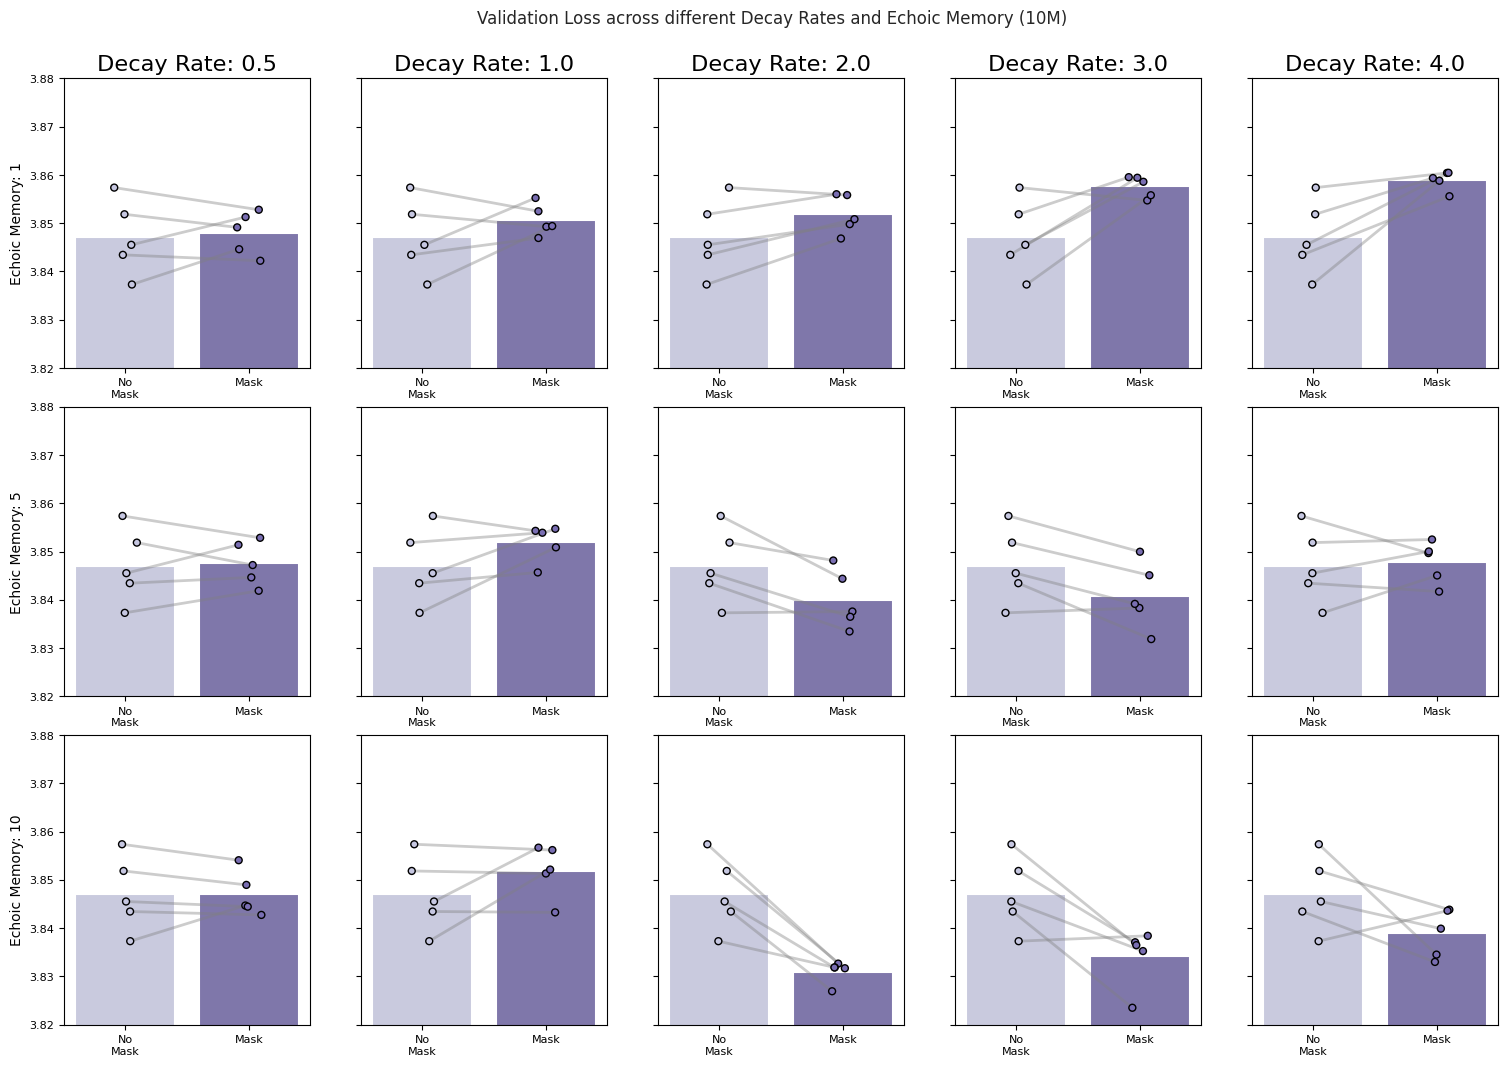

In [25]:

fig, axs = plt.subplots(3, 5, figsize=(15, 10))
fig.tight_layout()

print(len(seed_df_masks_10M['echoic_memory'].unique()))
print(len(seed_df_masks_10M[seed_df_masks_10M['x_condition'] != 'No\nMask']['x_condition'].unique()))
print(seed_df_masks_10M['echoic_memory'].unique())
print(seed_df_masks_10M[seed_df_masks_10M['x_condition'] != 'No\nMask']['x_condition'].unique())

with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    for i, em in enumerate(seed_df_masks_10M['echoic_memory'].unique()):
        for j, x_cond in enumerate(seed_df_masks_10M[seed_df_masks_10M['x_condition'] != 'No\nMask']['x_condition'].unique()):
            
            barplot_data = seed_df_masks_10M[(seed_df_masks_10M['echoic_memory'] == em) & (seed_df_masks_10M['x_condition'] == x_cond) | (seed_df_masks_10M['echoic_memory'] == 1) & (seed_df_masks_10M['x_condition'] == 'No\nMask')]
            barplot_data = barplot_data.sort_values(by='seed')
            barplot_data["x_condition"] = pd.Categorical(barplot_data["x_condition"], categories=["No\nMask", x_cond], ordered=True)

            stripplot_data = seed_df_masks_10M[(seed_df_masks_10M['echoic_memory'] == em) & (seed_df_masks_10M['x_condition'] == x_cond) | (seed_df_masks_10M['echoic_memory'] == 1) & (seed_df_masks_10M['x_condition'] == 'No\nMask')]
            stripplot_data = stripplot_data.sort_values(by='seed')
            stripplot_data["x_condition"] = pd.Categorical(stripplot_data["x_condition"], categories=["No\nMask", x_cond], ordered=True)

            barplot_data["x_condition"] = barplot_data["x_condition"].apply(lambda x: {x_cond: "Mask"}[x] if x != "No\nMask" else x)
            stripplot_data["x_condition"] = stripplot_data["x_condition"].apply(lambda x: {x_cond: "Mask"}[x] if x != "No\nMask" else x)
            
            sns.barplot(data=barplot_data, x='x_condition', y='val_loss', ax=axs[i, j], errorbar=None, palette="Purples_r", hue='condition')
            sns.stripplot(data=stripplot_data, x='x_condition', y='val_loss', ax=axs[i, j], palette="Purples_r", hue='condition', linewidth=1, edgecolor='black', alpha=1)
            
            if i == 0:
                axs[i, j].set_title(f"Decay Rate: {x_cond.split(' ')[1]}")

            axs[i, j].set_ylim(3.82, 3.88)
            
            axs[i,j].set_ylabel('')
            connect_dots(axs[i, j])
            
            if j != 0:
                axs[i, j].set_yticklabels([])
            else:
                axs[i, j].set_ylabel(f"Echoic Memory: {em}")
            
            axs[i, j].legend().remove()

            # for p in axs[i, j].patches:
            #     axs[i, j].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., (3.8+(0.75*0.1))) , ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=8)
            #print(barplot_data.columns)
            #Uncomment to get significance stars
            #res = annotate_given_colid(axs[i, j], 0, 1, barplot_data.assign(condition=lambda x: x['x_condition']), 0.5, 0.02, "val_loss")
            axs[i,j].set_xlabel('')
    fig.suptitle("Validation Loss across different Decay Rates and Echoic Memory (10M)", y=1.05)

    #save_matplot_fig(fig, "many_masking_val_loss_10M.png", dpi=1000)
    save_matplot_fig(fig, "many_masking_val_loss_emxdecay_10M.pdf", dpi=3000)

# NOTE: CODE BELOW DOES NOT WORK IN CURRENT VERSION



In [49]:
assert False, "Code below is not working in current version, Halt Execution"

AssertionError: Code below is not working in current version, Halt Execution

/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


Comparing Mask and No
Mask
{'mean                    ': -0.02235786914825453, '95%_CI around mean      ': (-0.024119974970817873, -0.02058522284030914), 'bootstrap-t-test p_value': 'p < 0.0001'}
Old y, h 3.475 0.003
Y lim values (3.3, 3.5)
New y, h 3.48 0.006000000000000005
[1.5 3. ]


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


Comparing Mask and No
Mask
{'mean                    ': 2.382027045560527, '95%_CI around mean      ': (1.391799382715059, 3.286535514823016), 'bootstrap-t-test p_value': 'p=0.0102'}
Old y, h 76.5 0.125
Y lim values (68.0, 78.0)
New y, h 77.0 0.3
[1.5 3. ]


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


Comparing Mask and No
Mask
{'mean                    ': -49.56005969300459, '95%_CI around mean      ': (-83.95175736644029, -14.956032638443304), 'bootstrap-t-test p_value': 'p=0.033'}
Old y, h 1850 12.5
Y lim values (1000.0, 2000.0)
New y, h 1900.0 30.0
mask_type
exponential_new    10
Non                10
Name: count, dtype: int64


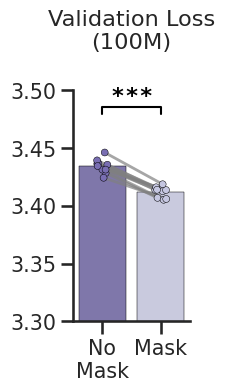

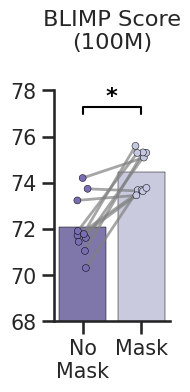

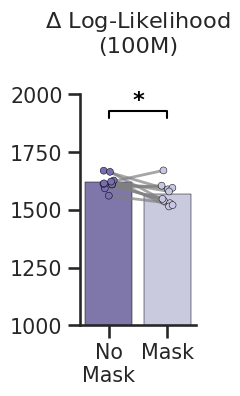

In [288]:

seed_df_100M = run_data_unfiltered[
    (run_data_unfiltered["curriculum_learning"] == False) & (run_data_unfiltered["dataset"] == "babylm_full_bpe_100M_8k") & 
    (run_data_unfiltered["n_layer"] == 6) & (run_data_unfiltered["batch_size"] == 32) & (run_data_unfiltered["num_iterations"] == 44000)
    & (((run_data_unfiltered["mask_type"].isin(["Non"]))  & (run_data_unfiltered["run_id"] != 5496427))
        | ((run_data_unfiltered["mask_type"].isin(["exponential_new"])) & (run_data_unfiltered["mask_decay_rate"] == 2) & (run_data_unfiltered["echoic_memory"] == 10) & (run_data_unfiltered["run_id"] != 8456913)))
][["run_id", "output_folder_name", "n_layer", "n_head", "block_size", "n_embd", "batch_size", "learning_rate", "mask_type", "mask_decay_rate", "echoic_memory", "dataset", "seed"]].reset_index(drop=True)

seed_df_100M["condition"] = seed_df_100M["mask_type"].apply(lambda x: "Mask" if x != "Non" else "No\nMask")
seed_df_100M = seed_df_100M.sort_values(by=["seed", "condition"]).reset_index(drop=True)

seed_df_100M["condition"] = pd.Categorical(seed_df_100M["condition"], categories=["No\nMask", "Mask"], ordered=True)

seed_df_100M = seed_df_100M.merge(loss_data[['run_id', 'val_loss', 'train_loss']], on="run_id", how="left")
seed_df_100M = seed_df_100M.merge(blimp_data[["run_id", "blimp_avg"]], on="run_id", how="left")
seed_df_100M = seed_df_100M.merge(reading_time_fit_df_osh[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_osh"), how="left", left_on="run_id", right_on="ModelID_osh",).drop(columns=["ModelID_osh"])
seed_df_100M["delta_log_likelihood_avg_osh"] = seed_df_100M["Delta Log-Likelihood_osh"] / seed_df_100M["Data Size_osh"]
seed_df_100M = seed_df_100M.merge(reading_time_fit_df_wil[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil"), how="left", left_on="run_id", right_on="ModelID_wil",).drop(columns=["ModelID_wil"])
seed_df_100M["delta_log_likelihood_avg_wil"] = seed_df_100M["Delta Log-Likelihood_wil"] / seed_df_100M["Data Size_wil"]
seed_df_100M = seed_df_100M.merge(reading_time_fit_df_wil2[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil2"), how="left", left_on="run_id", right_on="ModelID_wil2",).drop(columns=["ModelID_wil2"])
seed_df_100M["delta_log_likelihood_avg_wil2"] = seed_df_100M["Delta Log-Likelihood_wil2"] / seed_df_100M["Data Size_wil2"]


#Plot validation loss, BLIMP scores and reading time fit for 100M dataset

with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    fig, ax = plt.subplots(1, 1, figsize=(1.5, 3))
    sns.stripplot(data=seed_df_100M, x="condition", y="val_loss", hue = "condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=ax)
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_100M, x="condition", y="val_loss", hue="condition", palette="Purples_r", ax=ax, edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)
    
    ax.set_ylim(3.3,3.5)
    #ax.set_ylabel("Validation Loss (100M)")
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("Validation Loss\n(100M)", pad=30)
    
    annotate_given_colid(ax, 1, 0, seed_df_100M, 3.475, 0.003, "val_loss")
    sns.despine()
    print(fig.get_size_inches())
    save_matplot_fig(fig, "100M_pairwise_val_loss.png", dpi=1000, folders_path = "100M_pairwise_sep")
    save_matplot_fig(fig, "100M_pairwise_val_loss.pdf", dpi=3000, folders_path = "100M_pairwise_sep")

with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):

    #plt.figure(figsize=(1.5,3))
    fig, ax = plt.subplots(1, 1, figsize=(1.5, 3))
    sns.stripplot(data=seed_df_100M, x="condition", y="blimp_avg", hue = "condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=ax)
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_100M, x="condition", y="blimp_avg", hue="condition", palette="Purples_r", ax=ax, edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)
    
    ax.set_ylim(68, 78)
    #ax.set_ylabel("BLIMP Score")
    ax.set_ylabel("")
    ax.set_xlabel("")

    ax.set_title("BLIMP Score\n(100M)", pad=30)

    #Set number of y ticks as 5
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))    
    annotate_given_colid(ax, 1, 0, seed_df_100M, 76.5, 0.125, "blimp_avg")
    sns.despine()
    print(fig.get_size_inches())
    save_matplot_fig(fig, "100M_pairwise_blimp_score.png", dpi=1000, folders_path = "100M_pairwise_sep")
    save_matplot_fig(fig, "100M_pairwise_blimp_score.pdf", dpi=3000, folders_path = "100M_pairwise_sep")

with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    #plt.figure(figsize=(1.5,3))
    fig, ax = plt.subplots(1, 1, figsize=(1.5, 3))
    sns.stripplot(data=seed_df_100M, x="condition", y="Delta Log-Likelihood_osh", hue = "condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=ax)
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_100M, x="condition", y="Delta Log-Likelihood_osh", hue="condition", palette="Purples_r", ax=ax, edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)

    ax.set_ylim(1000,2000)
    ax.yaxis.set_major_locator(plt.MaxNLocator(4))
    #ax.set_ylabel("$\Delta$ Log-Likelihood")
    ax.set_ylabel("")
    ax.set_xlabel("")

    ax.set_title("$\Delta$ Log-Likelihood\n(100M)", pad=30)
    
    annotate_given_colid(ax, 1, 0, seed_df_100M, 1850, 12.5, "Delta Log-Likelihood_osh")
    sns.despine()
    save_matplot_fig(fig, "100M_pairwise_reading_time_fit.png", dpi=1000, folders_path = "100M_pairwise_sep")
    save_matplot_fig(fig, "100M_pairwise_reading_time_fit.pdf", dpi=3000, folders_path = "100M_pairwise_sep")


print(seed_df_100M["mask_type"].value_counts())
#seed_df_100M

/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Comparing Mask and No
Mask
{'mean                    ': -0.02235786914825453, '95%_CI around mean      ': (-0.024119974970817873, -0.02058522284030914), 'bootstrap-t-test p_value': 'p < 0.0001'}
Old y, h 3.475 0.003
Y lim values (3.3, 3.5)
New y, h 3.48 0.006000000000000005


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Comparing Mask and No
Mask
{'mean                    ': 2.382027045560527, '95%_CI around mean      ': (1.391799382715059, 3.286535514823016), 'bootstrap-t-test p_value': 'p=0.0102'}
Old y, h 76.5 0.125
Y lim values (68.0, 78.0)
New y, h 77.0 0.3


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Comparing Mask and No
Mask
{'mean                    ': -49.56005969300459, '95%_CI around mean      ': (-83.95175736644029, -14.956032638443304), 'bootstrap-t-test p_value': 'p=0.033'}
Old y, h 1850 12.5
Y lim values (1000.0, 2000.0)
New y, h 1900.0 30.0


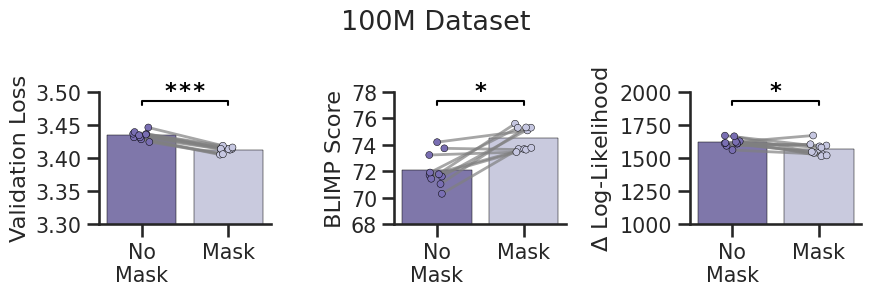

In [283]:
seed_df_100M = run_data_unfiltered[
    (run_data_unfiltered["curriculum_learning"] == False) & (run_data_unfiltered["dataset"] == "babylm_full_bpe_100M_8k") & 
    (run_data_unfiltered["n_layer"] == 6) & (run_data_unfiltered["batch_size"] == 32) & (run_data_unfiltered["num_iterations"] == 44000)
    & (((run_data_unfiltered["mask_type"].isin(["Non"]))  & (run_data_unfiltered["run_id"] != 5496427))
        | ((run_data_unfiltered["mask_type"].isin(["exponential_new"])) & (run_data_unfiltered["mask_decay_rate"] == 2) & (run_data_unfiltered["echoic_memory"] == 10) & (run_data_unfiltered["run_id"] != 8456913)))
][["run_id", "output_folder_name", "n_layer", "n_head", "block_size", "n_embd", "batch_size", "learning_rate", "mask_type", "mask_decay_rate", "echoic_memory", "dataset", "seed"]].reset_index(drop=True)

seed_df_100M["condition"] = seed_df_100M["mask_type"].apply(lambda x: "Mask" if x != "Non" else "No\nMask")
seed_df_100M = seed_df_100M.sort_values(by=["seed", "condition"]).reset_index(drop=True)

seed_df_100M["condition"] = pd.Categorical(seed_df_100M["condition"], categories=["No\nMask", "Mask"], ordered=True)

seed_df_100M = seed_df_100M.merge(loss_data[['run_id', 'val_loss', 'train_loss']], on="run_id", how="left")
seed_df_100M = seed_df_100M.merge(blimp_data[["run_id", "blimp_avg"]], on="run_id", how="left")
seed_df_100M = seed_df_100M.merge(reading_time_fit_df_osh[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_osh"), how="left", left_on="run_id", right_on="ModelID_osh",).drop(columns=["ModelID_osh"])
seed_df_100M["delta_log_likelihood_avg_osh"] = seed_df_100M["Delta Log-Likelihood_osh"] / seed_df_100M["Data Size_osh"]
seed_df_100M = seed_df_100M.merge(reading_time_fit_df_wil[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil"), how="left", left_on="run_id", right_on="ModelID_wil",).drop(columns=["ModelID_wil"])
seed_df_100M["delta_log_likelihood_avg_wil"] = seed_df_100M["Delta Log-Likelihood_wil"] / seed_df_100M["Data Size_wil"]
seed_df_100M = seed_df_100M.merge(reading_time_fit_df_wil2[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil2"), how="left", left_on="run_id", right_on="ModelID_wil2",).drop(columns=["ModelID_wil2"])
seed_df_100M["delta_log_likelihood_avg_wil2"] = seed_df_100M["Delta Log-Likelihood_wil2"] / seed_df_100M["Data Size_wil2"]

# Plot validation loss, BLIMP scores and reading time fit for 100M dataset
with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    fig, axs = plt.subplots(1, 3, figsize=(9, 3))

    # Validation Loss
    ax = sns.stripplot(data=seed_df_100M, x="condition", y="val_loss", hue="condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=axs[0])
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_100M, x="condition", y="val_loss", hue="condition", palette="Purples_r", ax=axs[0], edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)
    axs[0].set_ylim(3.3, 3.5)
    axs[0].set_ylabel("Validation Loss")
    axs[0].set_xlabel("")
    #axs[0].set_title("Validation Loss\n(100M)", pad=30)
    axs[0].yaxis.set_major_locator(plt.MaxNLocator(5))
    annotate_given_colid(axs[0], 1, 0, seed_df_100M, 3.475, 0.003, "val_loss")
    axs[0].legend().remove()
    sns.despine(ax=axs[0])

    # BLIMP Score
    ax = sns.stripplot(data=seed_df_100M, x="condition", y="blimp_avg", hue="condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=axs[1])
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_100M, x="condition", y="blimp_avg", hue="condition", palette="Purples_r", ax=axs[1], edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)
    axs[1].set_ylim(68, 78)
    axs[1].set_ylabel("BLIMP Score")
    axs[1].set_xlabel("")
    #axs[1].set_title("BLIMP Score\n(100M)", pad=30)
    axs[1].yaxis.set_major_locator(plt.MaxNLocator(5))
    annotate_given_colid(axs[1], 1, 0, seed_df_100M, 76.5, 0.125, "blimp_avg")
    axs[1].legend().remove()
    sns.despine(ax=axs[1])

    # Reading Time Fit
    ax = sns.stripplot(data=seed_df_100M, x="condition", y="Delta Log-Likelihood_osh", hue="condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=axs[2])
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_100M, x="condition", y="Delta Log-Likelihood_osh", hue="condition", palette="Purples_r", ax=axs[2], edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)
    axs[2].set_ylim(1000, 2000)
    axs[2].yaxis.set_major_locator(plt.MaxNLocator(4))
    axs[2].set_ylabel("$\Delta$ Log-Likelihood")
    axs[2].set_xlabel("")
    #axs[2].set_title("$\Delta$ Log-Likelihood\n(100M)", pad=30)
    annotate_given_colid(axs[2], 1, 0, seed_df_100M, 1850, 12.5, "Delta Log-Likelihood_osh")
    axs[2].legend().remove()
    sns.despine(ax=axs[2])

    
    fig.suptitle("100M Dataset", y = 1)
    plt.tight_layout()
    plt.show()

    save_matplot_fig(fig, "100M_pairwise_results_combined.png", dpi=1000)
    save_matplot_fig(fig, "100M_pairwise_results_combined.pdf", dpi=3000)

In [242]:
#Since only 5 seed values are there for all different settings - 42, 466, 616, 1337, 2347


seed_df_masks_100M = run_data_unfiltered[
    (run_data_unfiltered["curriculum_learning"] == False) & (run_data_unfiltered["dataset"] == "babylm_full_bpe_100M_8k") & 
    (run_data_unfiltered["n_layer"] == 6) & (run_data_unfiltered["batch_size"] == 256) & (run_data_unfiltered["num_iterations"] == 44000) 
    #& (run_data_unfiltered["seed"].isin([42, 466, 616, 1337, 2347]))
    & (((run_data_unfiltered["mask_type"].isin(["Non"]))  & (run_data_unfiltered["run_id"] != 5496427)) 
        | ((run_data_unfiltered["mask_type"].isin(["exponential_new"])) & (run_data_unfiltered["mask_decay_rate"].isin([0.5,1,2,3,4])) & (run_data_unfiltered["echoic_memory"].isin([1,5,10]))))
][["run_id", "output_folder_name", "n_layer", "n_head", "block_size", "n_embd", "batch_size", "learning_rate", "mask_type", "mask_decay_rate", "echoic_memory", "dataset", "seed"]].reset_index(drop=True)


seed_df_masks_100M = seed_df_masks_100M.sort_values(by=["mask_type", "mask_decay_rate", "echoic_memory", "seed"]).reset_index(drop=True)

seed_df_masks_100M["condition"] = seed_df_masks_100M["mask_type"].apply(lambda x: "Mask" if x != "Non" else "No\nMask")
seed_df_masks_100M["x_condition"] = seed_df_masks_100M["condition"] + " " + seed_df_masks_100M["mask_decay_rate"].astype(str).apply(lambda x: "" if x == "0.0" else x) 
seed_df_masks_100M["x_condition"] = seed_df_masks_100M["x_condition"].apply(lambda x: x.strip())

seed_df_masks_100M["condition"] = seed_df_masks_100M["condition"] + "\nEM" + seed_df_masks_100M["echoic_memory"].astype(str).str.zfill(2)
seed_df_masks_100M = seed_df_masks_100M.sort_values(by=["seed", "condition"]).reset_index(drop=True)

seed_df_masks_100M = seed_df_masks_100M.merge(loss_data[['run_id', 'val_loss', 'train_loss']], on="run_id", how="left")


seed_df_masks_100M["echoic_memory_flag"] = seed_df_masks_100M["echoic_memory"].apply(lambda x: False if x == 1 else True)

seed_df_masks_100M.sort_values(by=['x_condition', 'echoic_memory', 'seed'], inplace=True)
seed_df_masks_100M.reset_index(drop=True, inplace=True)

seed_df_masks_100M

,run_id,output_folder_name,n_layer,n_head,block_size,n_embd,batch_size,learning_rate,mask_type,mask_decay_rate,echoic_memory,dataset,seed,condition,x_condition,val_loss,train_loss,echoic_memory_flag
0,8178952,out-babylm_full_bpe_100M_8k-6x6-mask_ee0p5_em1...,6,6,256,384,256.0,0.00141,exponential_new,0.5,10,babylm_full_bpe_100M_8k,9,Mask\nEM10,Mask 0.5,3.326908,3.237979,True
1,8175589,out-babylm_full_bpe_100M_8k-6x6-mask_ee0p5_em1...,6,6,256,384,256.0,0.00141,exponential_new,0.5,10,babylm_full_bpe_100M_8k,42,Mask\nEM10,Mask 0.5,3.322266,3.230961,True
2,8182744,out-babylm_full_bpe_100M_8k-6x6-mask_ee0p5_em1...,6,6,256,384,256.0,0.00141,exponential_new,0.5,10,babylm_full_bpe_100M_8k,466,Mask\nEM10,Mask 0.5,3.318472,3.227038,True
3,8178972,out-babylm_full_bpe_100M_8k-6x6-mask_ee0p5_em1...,6,6,256,384,256.0,0.00141,exponential_new,0.5,10,babylm_full_bpe_100M_8k,616,Mask\nEM10,Mask 0.5,3.321950,3.233618,True
4,8182743,out-babylm_full_bpe_100M_8k-6x6-mask_ee0p5_em1...,6,6,256,384,256.0,0.00141,exponential_new,0.5,10,babylm_full_bpe_100M_8k,869,Mask\nEM10,Mask 0.5,3.324234,3.238602,True
5,8173546,out-babylm_full_bpe_100M_8k-6x6-mask_ee0p5_em1...,6,6,256,384,256.0,0.00141,exponential_new,0.5,10,babylm_full_bpe_100M_8k,1337,Mask\nEM10,Mask 0.5,3.328177,3.240427,True
6,8178694,out-babylm_full_bpe_100M_8k-6x6-mask_ee0p5_em1...,6,6,256,384,256.0,0.00141,exponential_new,0.5,10,babylm_full_bpe_100M_8k,2347,Mask\nEM10,Mask 0.5,3.323636,3.234818,True
7,8180899,out-babylm_full_bpe_100M_8k-6x6-mask_ee0p5_em1...,6,6,256,384,256.0,0.00141,exponential_new,0.5,10,babylm_full_bpe_100M_8k,6747,Mask\nEM10,Mask 0.5,3.321743,3.231329,True
8,8182745,out-babylm_full_bpe_100M_8k-6x6-mask_ee0p5_em1...,6,6,256,384,256.0,0.00141,exponential_new,0.5,10,babylm_full_bpe_100M_8k,11111,Mask\nEM10,Mask 0.5,3.320262,3.231371,True
9,8180897,out-babylm_full_bpe_100M_8k-6x6-mask_ee0p5_em1...,6,6,256,384,256.0,0.00141,exponential_new,0.5,10,babylm_full_bpe_100M_8k,46674,Mask\nEM10,Mask 0.5,3.323061,3.234438,True


2
3
[10  1]
['Mask 0.5' 'Mask 2.0' 'Mask 4.0']


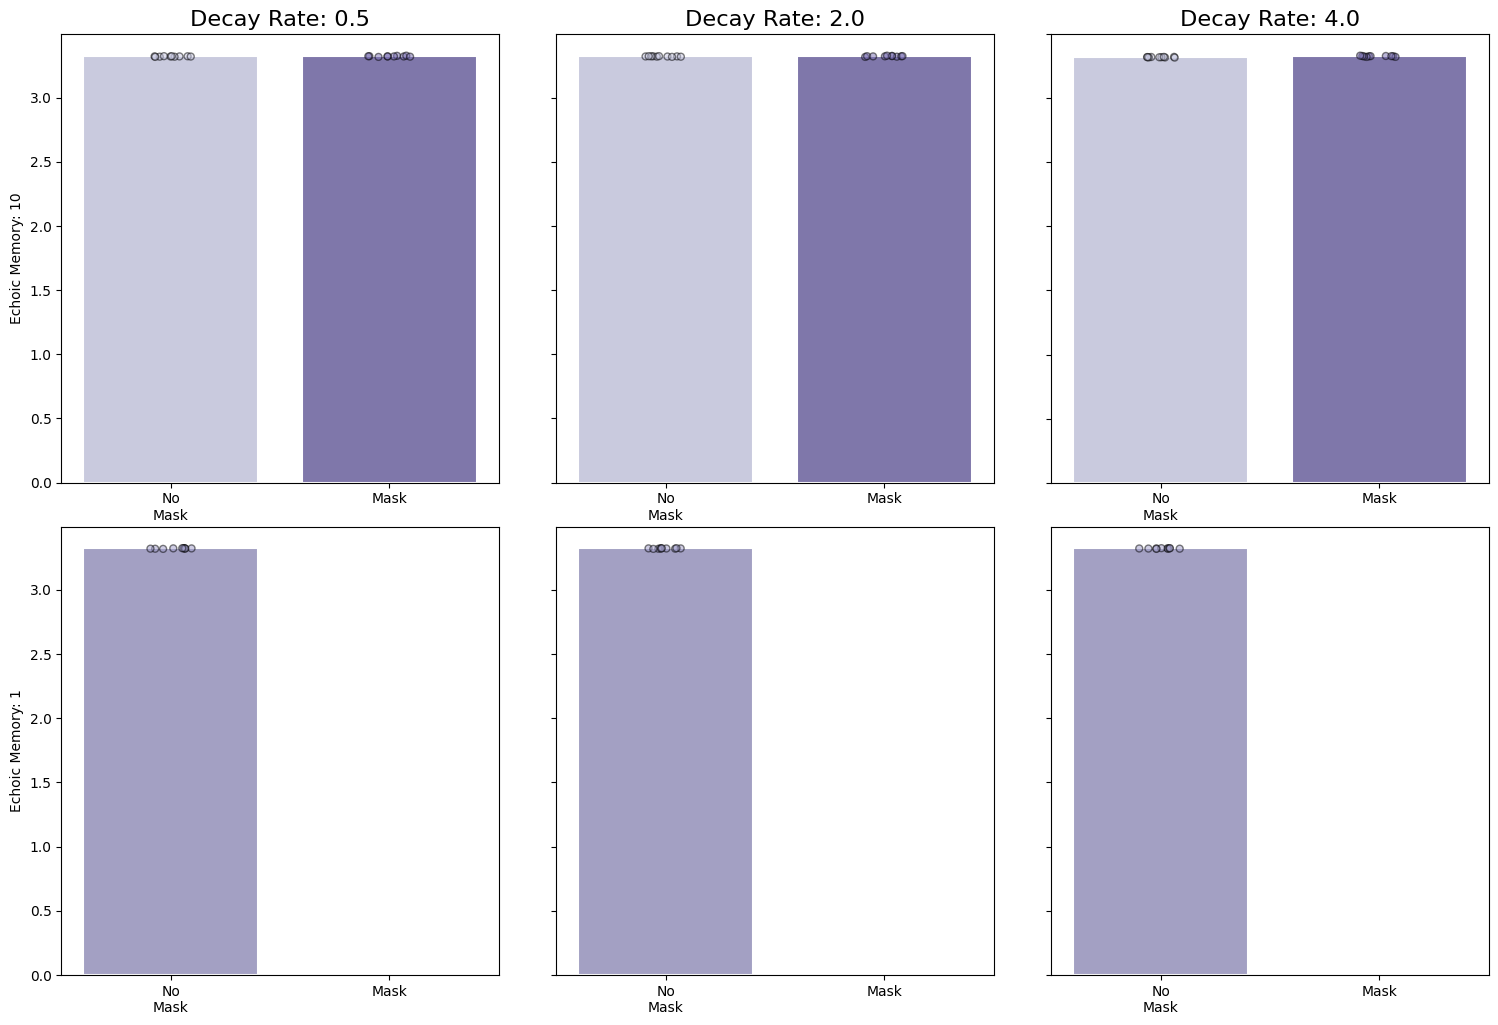

In [243]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.tight_layout()
print(len(seed_df_masks_100M['echoic_memory'].unique()))
print(len(seed_df_masks_100M[seed_df_masks_100M['x_condition'] != 'No\nMask']['x_condition'].unique()))
print(seed_df_masks_100M['echoic_memory'].unique())
print(seed_df_masks_100M[seed_df_masks_100M['x_condition'] != 'No\nMask']['x_condition'].unique())
with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    for i, em in enumerate(seed_df_masks_100M['echoic_memory'].unique()):
        for j, x_cond in enumerate(seed_df_masks_100M[seed_df_masks_100M['x_condition'] != 'No\nMask']['x_condition'].unique()):
            
            barplot_data = seed_df_masks_100M[(seed_df_masks_100M['echoic_memory'] == em) & (seed_df_masks_100M['x_condition'] == x_cond) | (seed_df_masks_100M['echoic_memory'] == 1) & (seed_df_masks_100M['x_condition'] == 'No\nMask')]
            barplot_data = barplot_data.sort_values(by='seed')
            barplot_data["x_condition"] = pd.Categorical(barplot_data["x_condition"], categories=["No\nMask", x_cond], ordered=True)

            stripplot_data = seed_df_masks_100M[(seed_df_masks_100M['echoic_memory'] == em) & (seed_df_masks_100M['x_condition'] == x_cond) | (seed_df_masks_100M['echoic_memory'] == 1) & (seed_df_masks_100M['x_condition'] == 'No\nMask')]
            stripplot_data = stripplot_data.sort_values(by='seed')
            stripplot_data["x_condition"] = pd.Categorical(stripplot_data["x_condition"], categories=["No\nMask", x_cond], ordered=True)

            barplot_data["x_condition"] = barplot_data["x_condition"].apply(lambda x: {x_cond: "Mask"}[x] if x != "No\nMask" else x)
            stripplot_data["x_condition"] = stripplot_data["x_condition"].apply(lambda x: {x_cond: "Mask"}[x] if x != "No\nMask" else x)
            
            sns.barplot(data=barplot_data, x='x_condition', y='val_loss', ax=axs[i, j], errorbar=None, palette="Purples_r", hue='condition')
            sns.stripplot(data=stripplot_data, x='x_condition', y='val_loss', ax=axs[i, j], alpha=0.5, palette="Purples_r", hue='condition', edgecolor='black', linewidth=1)
            
            if i == 0:
                axs[i, j].set_title(f"Decay Rate: {x_cond.split(' ')[1]}")

            #axs[i, j].set_ylim(3.75, 4)
            axs[i,j].set_xlabel('')
            axs[i,j].set_ylabel('')
            #connect_dots(axs[i, j])
            
            if j != 0:
                axs[i, j].set_yticklabels([])
            else:
                axs[i, j].set_ylabel(f"Echoic Memory: {em}")
            
            axs[i, j].legend().remove()
            # for p in axs[i, j].patches:
            #     axs[i, j].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.025), ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=8)


condition
No\nMask    10
Mask        10
Name: count, dtype: int64
Comparing Mask and No
Mask


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


{'mean                    ': -0.013513422012329145, '95%_CI around mean      ': (-0.017659356594086007, -0.00898563385009757), 'bootstrap-t-test p_value': 'p=0.0012'}
Old y, h 3.875 0.0015
Y lim values (3.8, 3.9)
New y, h 3.8899999999999997 0.0030000000000000027
[1.5 3. ]


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


Comparing Mask and No
Mask
{'mean                    ': 1.039780616572982, '95%_CI around mean      ': (0.5161924435294771, 1.544281033669681), 'bootstrap-t-test p_value': 'p=0.0086'}
Old y, h 72 0.25
Y lim values (65.0, 75.0)
New y, h 74.0 0.3
[1.5 3. ]


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])


Comparing Mask and No
Mask
{'mean                    ': -74.40259675537236, '95%_CI around mean      ': (-112.11606486887436, -36.135559619224196), 'bootstrap-t-test p_value': 'p=0.0104'}
Old y, h 1850 25
Y lim values (1000.0, 2000.0)
New y, h 1900.0 30.0


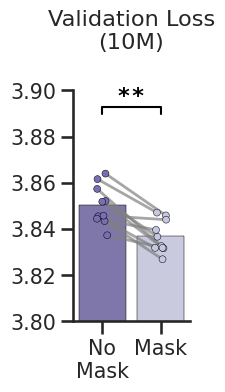

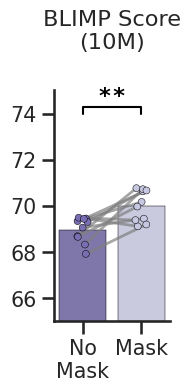

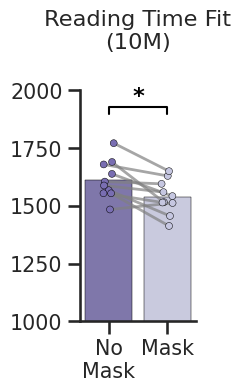

In [ ]:

# Best masking figures for 10M dataset - Filter for 10M dataset for no mask and mask decay rate 2 EM 10, Plot for validation loss and BLIMP scores and reading time fit

seed_df_10M = run_data_unfiltered[
    (run_data_unfiltered["curriculum_learning"] == False) & (run_data_unfiltered["dataset"] == "babylm_full_bpe_8k") & 
    (run_data_unfiltered["n_layer"] == 6) & (run_data_unfiltered["batch_size"] == 32) & (run_data_unfiltered["num_iterations"] == 44000)
    & (((run_data_unfiltered["mask_type"].isin(["Non"]))  & (run_data_unfiltered["run_id"] != 5496427)) #(do you have vector format?) - In Canva

# * Figure 4 from thesis (Effect of masking on performance for cross entropy loss)
# * Figure 5 from thesis (

seed_df_10M["condition"] = seed_df_10M["mask_type"].apply(lambda x: "Mask" if x != "Non" else "No\nMask")
seed_df_10M = seed_df_10M.sort_values(by=["seed", "condition"]).reset_index(drop=True)
seed_df_10M["condition"] = pd.Categorical(seed_df_10M["condition"], categories=["No\nMask", "Mask"], ordered=True)
print(seed_df_10M["condition"].value_counts())

seed_df_10M = seed_df_10M.merge(loss_data[['run_id', 'val_loss', 'train_loss']], on="run_id", how="left")
seed_df_10M = seed_df_10M.merge(blimp_data[["run_id", "blimp_avg"]], on="run_id", how="left")
seed_df_10M = seed_df_10M.merge(reading_time_fit_df_osh[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_osh"), how="left", left_on="run_id", right_on="ModelID_osh",).drop(columns=["ModelID_osh"])
seed_df_10M["delta_log_likelihood_avg_osh"] = seed_df_10M["Delta Log-Likelihood_osh"] / seed_df_10M["Data Size_osh"]
seed_df_10M = seed_df_10M.merge(reading_time_fit_df_wil[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil"), how="left", left_on="run_id", right_on="ModelID_wil",).drop(columns=["ModelID_wil"])
seed_df_10M["delta_log_likelihood_avg_wil"] = seed_df_10M["Delta Log-Likelihood_wil"] / seed_df_10M["Data Size_wil"]
seed_df_10M = seed_df_10M.merge(reading_time_fit_df_wil2[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil2"), how="left", left_on="run_id", right_on="ModelID_wil2",).drop(columns=["ModelID_wil2"])
seed_df_10M["delta_log_likelihood_avg_wil2"] = seed_df_10M["Delta Log-Likelihood_wil2"] / seed_df_10M["Data Size_wil2"]


#Plot validation loss, BLIMP scores and reading time fit for 10M dataset

with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    #plt.figure(figsize=(1.5,3))
    fig, ax = plt.subplots(1, 1, figsize=(1.5,3))
    sns.stripplot(data=seed_df_10M, x="condition", y="val_loss", hue = "condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=ax)
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_10M, x="condition", y="val_loss", hue="condition", palette="Purples_r", ax=ax, edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)
    
    ax.set_ylim(3.8, 3.9)
    #ax.set_ylabel("Validation Loss")
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("Validation Loss\n(10M)", pad=30)
    annotate_given_colid(ax, 1, 0, seed_df_10M, 3.875, 0.0015, "val_loss")
    sns.despine()
    print(fig.get_size_inches())
    save_matplot_fig(fig, "10M_pairwise_val_loss.png", dpi=1000, folders_path="10M_pairwise_sep")
    save_matplot_fig(fig, "10M_pairwise_val_loss.pdf", dpi=3000, folders_path="10M_pairwise_sep")

with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    fig, ax = plt.subplots(1, 1, figsize=(1.5,3))
    sns.stripplot(data=seed_df_10M, x="condition", y="blimp_avg", hue = "condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=ax)
    connect_dots(ax, alpha=0.7) (do you have vector format?) - In Canva

# * Figure 4 from thesis (Effect of masking on performance for cross entropy loss)
# * Figure 5 from thesis (
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("BLIMP Score\n(10M)", pad=30)
    #Set number of y ticks as 5
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))    
    annotate_given_colid(ax, 1, 0, seed_df_10M, 72, 0.25, "blimp_avg")
    sns.despine()
    print(fig.get_size_inches())
    save_matplot_fig(fig, "10M_pairwise_blimp_score.png", dpi=1000, folders_path="10M_pairwise_sep")
    save_matplot_fig(fig, "10M_pairwise_blimp_score.pdf", dpi=3000, folders_path="10M_pairwise_sep")
#seed_df_10M

with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    #plt.figure(figsize=(1.5,3))
    fig, ax = plt.subplots(1, 1, figsize=(1.5,3))   
    sns.stripplot(data=seed_df_10M, x="condition", y="Delta Log-Likelihood_osh", hue = "condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=ax) (do you have vector format?) - In Canva

# * Figure 4 from thesis (Effect of masking on performance for cross entropy loss)
# * Figure 5 from thesis (
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_10M, x="condition", y="Delta Log-Likelihood_osh", hue="condition", palette="Purples_r", ax=ax, edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)

    ax.set_ylim(1000,2000)
    ax.yaxis.set_major_locator(plt.MaxNLocator(4))
    #ax.set_ylabel("$\Delta$ Log-Likelihood")
    
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("Reading Time Fit\n(10M)", pad=30)
    annotate_given_colid(ax, 1, 0, seed_df_10M, 1850, 25, "Delta Log-Likelihood_osh") (do you have vector format?) - In Canva

# * Figure 4 from thesis (Effect of masking on performance for cross entropy loss)
# * Figure 5 from thesis (
    save_matplot_fig(fig, "10M_pairwise_reading_time_fit.png", dpi=1000, folders_path="10M_pairwise_sep")
    save_matplot_fig(fig, "10M_pairwise_reading_time_fit.pdf", dpi=3000, folders_path="10M_pairwise_sep")



condition
No\nMask    10
Mask        10
Name: count, dtype: int64
Comparing Mask and No
Mask


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


{'mean                    ': -0.013513422012329145, '95%_CI around mean      ': (-0.017659356594086007, -0.00898563385009757), 'bootstrap-t-test p_value': 'p=0.0012'}
Old y, h 3.875 0.0015
Y lim values (3.8, 3.9)
New y, h 3.8899999999999997 0.0030000000000000027
Comparing Mask and No
Mask


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


{'mean                    ': 1.039780616572982, '95%_CI around mean      ': (0.5161924435294771, 1.544281033669681), 'bootstrap-t-test p_value': 'p=0.0086'}
Old y, h 73 0.25
Y lim values (65.0, 75.0)
New y, h 74.0 0.3
Comparing Mask and No
Mask


/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


{'mean                    ': -74.40259675537236, '95%_CI around mean      ': (-112.11606486887436, -36.135559619224196), 'bootstrap-t-test p_value': 'p=0.0104'}
Old y, h 1850 25
Y lim values (1000.0, 2000.0)
New y, h 1900.0 30.0


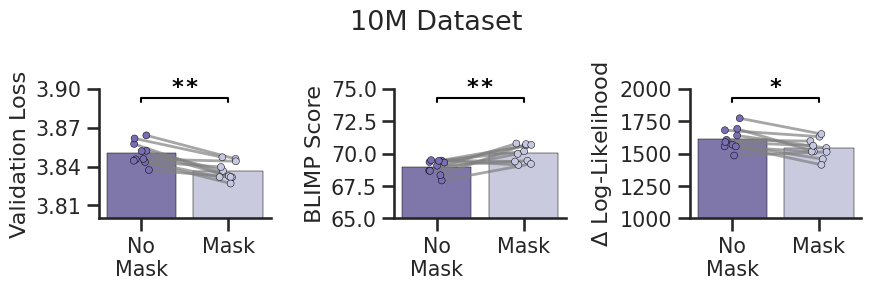

In [ ]:
# Best masking figures for 10M dataset - Filter for 10M dataset for no mask and mask decay rate 2 EM 10, Plot for validation loss and BLIMP scores and reading time fit

seed_df_10M = run_data_unfiltered[
    (run_data_unfiltered["curriculum_learning"] == False) & (run_data_unfiltered["dataset"] == "babylm_full_bpe_8k") & 
    (run_data_unfiltered["n_layer"] == 6) & (run_data_unfiltered["batch_size"] == 32) & (run_data_unfiltered["num_iterations"] == 44000)
    & (((run_data_unfiltered["mask_type"].isin(["Non"]))  & (run_data_unfiltered["run_id"] != 5496427))
        | ((run_data_unfiltered["mask_type"].isin(["exponential_new"])) & (run_data_unfiltered["mask_decay_rate"] == 2) & (run_data_unfiltered["echoic_memory"] == 10)))
][["run_id", "output_folder_name", "n_layer", "n_head", "block_size", "n_embd", "batch_size", "learning_rate", "mask_type", "mask_decay_rate", "echoic_memory", "dataset", "seed"]].reset_index(drop=True)

seed_df_10M["condition"] = seed_df_10M["mask_type"].apply(lambda x: "Mask" if x != "Non" else "No\nMask")
seed_df_10M = seed_df_10M.sort_values(by=["seed", "condition"]).reset_index(drop=True)
seed_df_10M["condition"] = pd.Categorical(seed_df_10M["condition"], categories=["No\nMask", "Mask"], ordered=True)
print(seed_df_10M["condition"].value_counts())

seed_df_10M = seed_df_10M.merge(loss_data[['run_id', 'val_loss', 'train_loss']], on="run_id", how="left")
seed_df_10M = seed_df_10M.merge(blimp_data[["run_id", "blimp_avg"]], on="run_id", how="left")
seed_df_10M = seed_df_10M.merge(reading_time_fit_df_osh[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_osh"), how="left", left_on="run_id", right_on="ModelID_osh",).drop(columns=["ModelID_osh"])
seed_df_10M["delta_log_likelihood_avg_osh"] = seed_df_10M["Delta Log-Likelihood_osh"] / seed_df_10M["Data Size_osh"]
seed_df_10M = seed_df_10M.merge(reading_time_fit_df_wil[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil"), how="left", left_on="run_id", right_on="ModelID_wil",).drop(columns=["ModelID_wil"])
seed_df_10M["delta_log_likelihood_avg_wil"] = seed_df_10M["Delta Log-Likelihood_wil"] / seed_df_10M["Data Size_wil"]
seed_df_10M = seed_df_10M.merge(reading_time_fit_df_wil2[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil2"), how="left", left_on="run_id", right_on="ModelID_wil2",).drop(columns=["ModelID_wil2"])
seed_df_10M["delta_log_likelihood_avg_wil2"] = seed_df_10M["Delta Log-Likelihood_wil2"] / seed_df_10M["Data Size_wil2"]

# Plot validation loss, BLIMP scores and reading time fit for 10M dataset
with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    fig, axs = plt.subplots(1, 3, figsize=(9, 3))

    # Validation Loss
    ax = sns.stripplot(data=seed_df_10M, x="condition", y="val_loss", hue="condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=axs[0])
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_10M, x="condition", y="val_loss", hue="condition", palette="Purples_r", ax=axs[0], edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)
    axs[0].set_ylim(3.8, 3.9)
    axs[0].set_ylabel("Validation Loss")
    axs[0].set_xlabel("")
    axs[0].yaxis.set_major_locator(plt.MaxNLocator(4))
    annotate_given_colid(axs[0], 1, 0, seed_df_10M, 3.875, 0.0015, "val_loss")
    axs[0].legend().remove()
    sns.despine(ax=axs[0])

    # BLIMP Score
    ax = sns.stripplot(data=seed_df_10M, x="condition", y="blimp_avg", hue="condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=axs[1])
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_10M, x="condition", y="blimp_avg", hue="condition", palette="Purples_r", ax=axs[1], edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)
    axs[1].set_ylim(65, 75)
    axs[1].set_ylabel("BLIMP Score")
    axs[1].set_xlabel("")
    axs[1].yaxis.set_major_locator(plt.MaxNLocator(4))
    annotate_given_colid(axs[1], 1, 0, seed_df_10M, 73, 0.25, "blimp_avg")
    axs[1].legend().remove()
    sns.despine(ax=axs[1])

    # Reading Time Fit (do you have vector format?) - In Canva

# * Figure 4 from thesis (Effect of masking on performance for cross entropy loss)
# * Figure 5 from thesis (
    ax = sns.stripplot(data=seed_df_10M, x="condition", y="Delta Log-Likelihood_osh", hue="condition", palette="Purples_r", edgecolor='k', linewidth=0.35, ax=axs[2])
    connect_dots(ax, alpha=0.7)
    sns.barplot(data=seed_df_10M, x="condition", y="Delta Log-Likelihood_osh", hue="condition", palette="Purples_r", ax=axs[2], edgecolor='k', linewidth=0.35, errorbar=None, alpha=1)
    axs[2].set_ylim(1000, 2000)
    axs[2].yaxis.set_major_locator(plt.MaxNLocator(4))
    axs[2].set_ylabel("$\Delta$ Log-Likelihood")
    axs[2].set_xlabel("")
    annotate_given_colid(axs[2], 1, 0, seed_df_10M, 1850, 25, "Delta Log-Likelihood_osh")
    axs[2].legend().remove()
    sns.despine(ax=axs[2])

    fig.suptitle("10M Dataset")
    fig.tight_layout()
    plt.tight_layout()
    plt.show()


save_matplot_fig(fig, "10M_Pairwise_results_combined.png", dpi=1000)


/tmp/ipykernel_476852/2698798670.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data["condition"] = pd.Categorical(plot_data["condition"], categories=[no_mask_condition, condition_name], ordered=True)
/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col

Comparing Mask
EM 5 and No
Mask
{'mean                    ': -0.005926585197448553, '95%_CI around mean      ': (-0.008891927599906915, -0.0027906960248944047), 'bootstrap-t-test p_value': 'p=0.0138'}
Old y, h 3.875 0.002
Y lim values (3.75, 3.94)
New y, h 3.8906 0.0056999999999999985


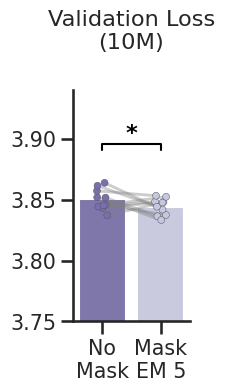

/tmp/ipykernel_476852/2698798670.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data["condition"] = pd.Categorical(plot_data["condition"], categories=[no_mask_condition, condition_name], ordered=True)
/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col

Comparing Mask
EM 10 and No
Mask
{'mean                    ': -0.013513422012329145, '95%_CI around mean      ': (-0.017659356594086007, -0.00898563385009757), 'bootstrap-t-test p_value': 'p=0.0012'}
Old y, h 3.875 0.002
Y lim values (3.75, 3.94)
New y, h 3.8906 0.0056999999999999985


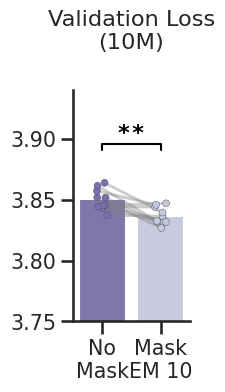

/tmp/ipykernel_476852/2698798670.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data["condition"] = pd.Categorical(plot_data["condition"], categories=[no_mask_condition, condition_name], ordered=True)
/tmp/ipykernel_476852/1629932896.py:332: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col

Comparing Mask
No EM and No
Mask
{'mean                    ': 0.007327985763549849, '95%_CI around mean      ': (0.004357456564903219, 0.01030530214309719), 'bootstrap-t-test p_value': 'p=0.0008'}
Old y, h 3.875 0.002
Y lim values (3.75, 3.94)
New y, h 3.8906 0.0056999999999999985


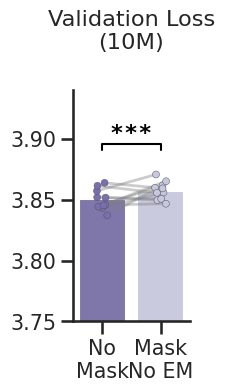

     pair_A       pair_B  mean                      \
0  No\nMask   Mask\nEM 5                 -0.005927   
1  No\nMask  Mask\nEM 10                 -0.013513   
2  No\nMask  Mask\nNo EM                  0.007328   

                          95%_CI around mean       bootstrap-t-test p_value  
0  (-0.008891927599906915, -0.0027906960248944047)                 p=0.0138  
1    (-0.017659356594086007, -0.00898563385009757)                 p=0.0012  
2      (0.004357456564903219, 0.01030530214309719)                 p=0.0008  


In [ ]:
condition_triplet_map = {"nomask_EM01": "No\nMask", 
                         "ee002_EM01": "Mask\nNo EM", 
                         "ee002_EM05": "Mask\nEM 5", 
                         "ee002_EM10": "Mask\nEM 10"}

with sns.axes_style("ticks"), sns.plotting_context("talk", font_scale=.9):
    stats_test = []
    plot_data_r = seed_df.merge(loss_data, on="run_id", how="left")[["seed", "condition", "val_loss"]]
    plot_data_r = plot_data_r[plot_data_r["condition"].isin(["nomask_EM01", "ee002_EM01", "ee002_EM05", "ee002_EM10"])]
    plot_data_r["condition"] = pd.Categorical(plot_data_r["condition"], categories=["nomask_EM01", "ee002_EM01", "ee002_EM05", "ee002_EM10"], ordered=True)
    plot_data_r["condition"] = plot_data_r["condition"].map(condition_triplet_map)
    plot_data_r["condition"] = plot_data_r["condition"].astype(str)
    #plot_data_r.remove_categories(condition_triplet_map.values())
    #print(plot_data_r)
    #print(plot_data_r["condition"].unique())
    no_mask_condition = "No\nMask"
    
    for condition_name in plot_data_r["condition"].unique():
        #print("H1", condition)
        if condition_name != no_mask_condition:
            fig, ax = plt.subplots(1, 1, figsize=(1.5, 3))
            #plt.figure(figsize=(1.5, 3))
            plot_data = plot_data_r[plot_data_r["condition"].isin([no_mask_condition, condition_name])]
            #plot_data = plot_data.reset_index(drop=True)
            plot_data["condition"] = pd.Categorical(plot_data["condition"], categories=[no_mask_condition, condition_name], ordered=True)
            # print(plot_data)
            # print(plot_data.columns)
            # print(plot_data["condition"].unique())
            # #print(plot_data["condition"].cat.categories)
            sns.barplot(data=plot_data[["condition", "val_loss"]], x="condition", y="val_loss", hue="condition",  ax=ax,
                        errorbar=None, palette="Purples_r")
            
            sns.stripplot(data=plot_data[["condition", "val_loss"]], x="condition", y="val_loss", ax=ax, linewidth=0.35, palette="Purples_r", hue="condition")
            
            connect_dots(ax)

            #ax.axhline(y=plot_data[plot_data["condition"] == "No Mask"]["val_loss"].mean(), linestyle='--', color='red')

            #ax.set_ylabel("Validation Loss")
            ax.set_ylabel("")
            ax.set_ylim(3.78, 3.94)
            ax.set_xlabel("")
            ax.set_yticks(ax.get_yticks()[ax.get_yticks() <= 3.9])

            ax.set_title("Validation Loss\n(10M)", pad=30)

            # # Perform pairwise comparisons with "No Mask"
            res = annotate_given_colid(ax, plot_data["condition"].cat.categories.get_loc(condition_name), plot_data["condition"].cat.categories.get_loc(no_mask_condition), plot_data, 3.875, 0.002, "val_loss", h_factor=0.74) 

# * Figure 4 from thesis (Effect of masking on performance for cross entropy loss)
# * Figure 5 from thesis (
            save_matplot_fig(fig, f"NoMask_vs_{save_cond_name}_val_loss.png", dpi=1000, folders_path="figure_5_sep")
            save_matplot_fig(fig, f"NoMask_vs_{save_cond_name}_val_loss.pdf", dpi=3000, folders_path="figure_5_sep")

    print(pd.DataFrame(stats_test))
    #save_matplot_fig(fig, "pairwise_comp_val_loss_withstats_v2_mq", dpi=1000)
    #save_matplot_fig(fig, "pairwise_comp_val_loss_withstats_v2_hq.pdf", dpi=3000)
    #save_matplot_fig(fig, "Fig2_val_loss_strong_mask_EM.pdf", dpi=3000)
